# Analisi biometrica + Estrazione tabelle per la sezione Results

Notebook esteso rispetto alla versione precedente. Oltre a tutta
l'analisi gia' presente (bootstrap CI, normalita', ROC/DET, Wilcoxon,
confondimenti noti, SOTA, failure analysis, ecc.) aggiunge il blocco di
**estrazione dati puro** richiesto per riscrivere "Experimental Setup" e
"Results": legge i log di training grezzi + i CSV per-esperimento e
produce le Tabelle 1-5 richieste, in Markdown copia-incollabile.

Nuovo in questa versione:
1. Parsing dei log di training (writer count, coppie genuine/impostor,
   epoche, early stopping) — la versione precedente usava solo i CSV.
2. Le metriche puntuali (Tabelle 2-4) sono lette DIRETTAMENTE dal CSV
   (`_final_metrics.csv`), non ricalcolate via bootstrap, per rispettare
   la regola "CSV e' source of truth" della spec di estrazione. Il
   ricalcolo via bootstrap (gia' presente) resta disponibile per le CI e
   per i plot, come sezione separata.
3. Tabella 1 (protocollo writer/coppie) per split, dedotta dai log.
4. Tabelle 2/3 (AUC/EER, backbone x loss, per split) in Markdown.
5. Tabella 4 (long format completa) in Markdown, con colonna note per i
   modelli "collassati" (AUC ~ 0.5).
6. Tabella 5 (aggregato same/cross per loss) SOLO se tutti e 6 i
   backbone sono presenti per quella combinazione (loss, split);
   altrimenti riporta esplicitamente quali backbone mancano invece di
   calcolare una media parziale silenziosa.
7. Sezione "Missing configurations" esplicita (mai inventare/omettere
   silenziosamente una configurazione mancante).

Tutte le tabelle vengono anche salvate su disco come file `.md`
indipendenti, pronti per essere incollati in LaTeX/paper.

In [44]:
import warnings
warnings.filterwarnings('ignore')

import ast
import re
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, auc, confusion_matrix

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except (OSError, ValueError):
    plt.style.use('default')
sns.set_palette("husl")

Path('./images').mkdir(exist_ok=True)
Path('./tables').mkdir(exist_ok=True)

## Configurazione

In [45]:
results_base = Path('../results')

loss_types = ['bce', 'contrastive', 'triplet']
dataset_combinations = ['iam_to_iam', 'iam_to_rimes', 'rimes_to_iam', 'rimes_to_rimes']

MODELS_TO_ANALYZE = [
    'efficientnet_b0', 'efficientnet_b1',
    'mobilenet_v3_large', 'mobilenet_v3_small',
    'resnet18', 'resnet34',
]

REPRESENTATIVE_MODEL = 'resnet18'

N_BOOTSTRAP = 1000
CI_LEVEL = 95
BOOTSTRAP_SEED = 42

# Soglia sotto la quale un AUC viene considerato "collassato" (chance level)
AUC_COLLAPSE_THRESHOLD = 0.55

## Caricamento dati: risoluzione path per CSV metriche/history + log grezzo

Come nella versione precedente, prova prima
`results_base/{loss}/{loss}_experiments/...`, poi come fallback
`results_base/{loss}_experiments/...`. Per il log grezzo (necessario
SOLO per l'estrazione delle statistiche di protocollo/writer e delle
dinamiche di training) si provano diversi nomi file plausibili: se il
tuo script di training usa un nome diverso, aggiungi il pattern alla
lista `log_name_candidates` qui sotto.

In [46]:
def resolve_experiment_path(loss, model_name, dataset_comb):
    experiment_name = f"{model_name}_{loss}_{dataset_comb}"
    candidates = [
        results_base / loss / f"{loss}_experiments" / experiment_name,
        results_base / f"{loss}_experiments" / experiment_name,
    ]
    for c in candidates:
        if (c / f"{experiment_name}_final_metrics.csv").exists():
            return c, experiment_name
    return None, experiment_name


def resolve_log_file(experiment_path, experiment_name):
    """Cerca il file di log grezzo (stdout capture) dell'esperimento.
    Ritorna il Path se trovato, altrimenti None. Adatta i pattern se il
    tuo script di training salva i log con un nome diverso."""
    if experiment_path is None:
        return None
    log_name_candidates = [
        f"{experiment_name}.log",
        f"{experiment_name}_log.txt",
        f"{experiment_name}_train.log",
        f"{experiment_name}_training.log",
        "train.log",
        "training.log",
        "log.txt",
        "stdout.log",
    ]
    for name in log_name_candidates:
        p = experiment_path / name
        if p.exists():
            return p
    # fallback: qualunque *.log nella cartella dell'esperimento
    logs = list(experiment_path.glob("*.log"))
    if logs:
        return logs[0]
    return None

## Parsing dei log grezzi

I log NON sono strutturati come JSON: si fa parsing testuale con regex
sui pattern descritti nella spec di estrazione. Il parser e' tollerante
(ritorna `None`/`np.nan` per i campi che non trova invece di sollevare
eccezioni) cosi' che un formato di log leggermente diverso non blocchi
l'intero notebook — i campi mancanti finiscono comunque nella sezione
"Missing configurations" / vengono segnalati come `NaN`.

In [47]:
def _find_int(pattern, text, flags=0):
    m = re.search(pattern, text, flags)
    if m:
        return int(m.group(1).replace(',', ''))
    return None


def parse_writer_counts(log_text):
    """Estrae il numero di writer per TRAIN/VAL/TEST.
    Pattern atteso: blocchi tipo
        Initializing TRAIN Siamese Dataset
        ...
        Writers: N
    Si assume che il blocco TEST non sia necessariamente etichettato come
    "Siamese Dataset" (spesso e' un blocco di valutazione separato): si
    cerca quindi anche un pattern generico "Writers: N" nei pressi della
    parola TEST/Evaluation, con fallback sul terzo valore "Writers: N"
    trovato nel file se non c'e' un'etichetta esplicita.
    """
    result = {'train_writers': None, 'val_writers': None, 'test_writers': None}

    block_pattern = re.compile(
        r"Initializing\s+(TRAIN|VAL|TEST)\s+Siamese\s+Dataset.*?Writers:\s*(\d+)",
        re.IGNORECASE | re.DOTALL,
    )
    for m in block_pattern.finditer(log_text):
        split_name = m.group(1).upper()
        n_writers = int(m.group(2))
        if split_name == 'TRAIN':
            result['train_writers'] = n_writers
        elif split_name == 'VAL':
            result['val_writers'] = n_writers
        elif split_name == 'TEST':
            result['test_writers'] = n_writers

    if result['test_writers'] is None:
        # fallback: cerca "Writers: N" vicino a TEST/Evaluation/Evaluating
        m = re.search(
            r"(TEST|Evaluat\w*)[^\n]{0,200}?Writers:\s*(\d+)",
            log_text, re.IGNORECASE | re.DOTALL,
        )
        if m:
            result['test_writers'] = int(m.group(2))

    return result


def parse_pair_counts(log_text):
    """Estrae i conteggi di coppie generate/campionate per TRAIN e VAL,
    piu' le coppie effettivamente valutate sul TEST (dal blocco FINAL
    COMPREHENSIVE VALIDATION)."""

    def counts_in_span(span_text):
        return {
            'genuine_pairs': _find_int(r"Generated\s+([\d,]+)\s+genuine\s+pairs", span_text, re.IGNORECASE),
            'impostor_pool': _find_int(r"Generated\s+([\d,]+)\s+total\s+impostor\s+pairs\s*\(pool\)", span_text, re.IGNORECASE),
            'sampled_impostors': _find_int(r"Sampled\s+([\d,]+)\s+impostors\s+from\s+pool\s+of\s+([\d,]+)", span_text, re.IGNORECASE),
        }

    result = {
        'train': {'genuine_pairs': None, 'impostor_pool': None, 'sampled_impostors': None},
        'val': {'genuine_pairs': None, 'impostor_pool': None, 'sampled_impostors': None},
        'test_genuine_evaluated': None,
        'test_impostor_evaluated': None,
    }

    # Split grezzo del log in blocchi TRAIN / VAL usando le stesse ancore
    # del parsing dei writer, cosi' i conteggi di coppie non si mescolano
    # tra train e val.
    train_block = re.search(
        r"Initializing\s+TRAIN\s+Siamese\s+Dataset(.*?)(?=Initializing\s+(VAL|TEST)\s+Siamese\s+Dataset|\Z)",
        log_text, re.IGNORECASE | re.DOTALL,
    )
    val_block = re.search(
        r"Initializing\s+VAL\s+Siamese\s+Dataset(.*?)(?=Initializing\s+(TRAIN|TEST)\s+Siamese\s+Dataset|\Z)",
        log_text, re.IGNORECASE | re.DOTALL,
    )
    if train_block:
        result['train'] = counts_in_span(train_block.group(1))
    if val_block:
        result['val'] = counts_in_span(val_block.group(1))

    m = re.search(
        r"Evaluated\s+([\d,]+)\s+genuine\s*\+\s*([\d,]+)\s+impostor\s+pairs",
        log_text, re.IGNORECASE,
    )
    if m:
        result['test_genuine_evaluated'] = int(m.group(1).replace(',', ''))
        result['test_impostor_evaluated'] = int(m.group(2).replace(',', ''))

    return result


def parse_training_dynamics(log_text):
    """Estrae epoche effettivamente eseguite, miglior val loss, e se e'
    scattato l'early stopping o e' stato raggiunto il cap di 50 epoche."""
    epoch_losses = re.findall(
        r"Train Loss:\s*([\d.]+)\s*\|\s*Val Loss:\s*([\d.]+)",
        log_text, re.IGNORECASE,
    )
    n_epochs_run = len(epoch_losses)
    best_val_loss = min((float(v) for _, v in epoch_losses), default=np.nan)

    early_stopped = bool(re.search(r"early\s*stop", log_text, re.IGNORECASE))
    hit_epoch_cap = (n_epochs_run >= 50) and not early_stopped

    return {
        'n_epochs_run': n_epochs_run if n_epochs_run > 0 else None,
        'best_val_loss': best_val_loss,
        'early_stopped': early_stopped,
        'hit_epoch_cap': hit_epoch_cap,
    }


def parse_log_full(log_path):
    if log_path is None or not log_path.exists():
        return None
    try:
        log_text = log_path.read_text(encoding='utf-8', errors='ignore')
    except Exception:
        return None

    parsed = {}
    parsed.update(parse_writer_counts(log_text))
    parsed['pairs'] = parse_pair_counts(log_text)
    parsed['dynamics'] = parse_training_dynamics(log_text)
    return parsed

## Colonne CSV attese (spec di estrazione) e mappatura

Il CSV `_final_metrics.csv` per-esperimento contiene una riga con queste
colonne (nomi esatti dalla spec). Le leggiamo cosi' come sono — nessun
ricalcolo — perche' il CSV e' la source of truth per le Tabelle 2-4.

In [48]:
CSV_POINT_COLUMNS = [
    'auc', 'eer', 'eer_threshold', 'accuracy', 'precision', 'recall', 'f1',
    'd_prime', 'decidability', 'mu_genuine', 'mu_impostor',
    'sigma_genuine', 'sigma_impostor',
    'far_0.001_effective', 'frr_at_far_0.001', 'gar_at_far_0.001', 'threshold_at_far_0.001',
    'far_0.01_effective', 'frr_at_far_0.01', 'gar_at_far_0.01', 'threshold_at_far_0.01',
]


def load_point_metrics_from_csv(metrics_df):
    """Estrae la riga di metriche puntuali dal CSV, cosi' come salvata
    dallo script di valutazione (nessun ricalcolo). Colonne mancanti nel
    CSV vengono riportate come NaN esplicito, mai inventate."""
    row = metrics_df.iloc[0]
    out = {}
    for col in CSV_POINT_COLUMNS:
        out[col] = row[col] if col in metrics_df.columns else np.nan
    return out


def is_far_degenerate(value):
    """FAR effettivo NaN o chiaramente degenere (es. 0 o negativo, che non
    ha senso come FAR realizzato) -> punto operativo non raggiungibile."""
    if value is None:
        return True
    try:
        v = float(value)
    except (TypeError, ValueError):
        return True
    return np.isnan(v)

## Caricamento completo: CSV (metriche + history) + log grezzo, per tutte
## le 72 configurazioni (backbone x loss x split)

In [49]:
all_results = {}          # per plotting/bootstrap (usa genuine_vals/impostor_vals)
point_metrics_csv = {}    # metriche puntuali lette DIRETTAMENTE dal CSV (source of truth)
protocol_by_split = {}    # statistiche di protocollo dai log, raccolte per split
training_dynamics = {}    # dinamiche di training dai log, per (loss, backbone, split)
missing_configs = []      # configurazioni (backbone,loss,split) del tutto assenti
missing_log_configs = []  # configurazioni con CSV presente ma log grezzo assente/non parsabile

for loss in loss_types:
    all_results.setdefault(loss, {})
    point_metrics_csv.setdefault(loss, {})
    training_dynamics.setdefault(loss, {})

    for model_name in MODELS_TO_ANALYZE:
        for dataset_comb in dataset_combinations:
            experiment_path, experiment_name = resolve_experiment_path(loss, model_name, dataset_comb)

            if experiment_path is None:
                missing_configs.append((model_name, loss, dataset_comb))
                continue

            metrics_file = experiment_path / f"{experiment_name}_final_metrics.csv"
            history_file = experiment_path / f"{experiment_name}_history.csv"

            if not (metrics_file.exists() and history_file.exists()):
                missing_configs.append((model_name, loss, dataset_comb))
                continue

            metrics_df = pd.read_csv(metrics_file)
            history_df = pd.read_csv(history_file)

            genuine_vals = np.array(ast.literal_eval(metrics_df['genuine_vals'].values[0]))
            impostor_vals = np.array(ast.literal_eval(metrics_df['impostor_vals'].values[0]))

            all_results[loss].setdefault(model_name, {})[dataset_comb] = {
                'metrics': metrics_df,
                'history': history_df,
                'genuine_vals': genuine_vals,
                'impostor_vals': impostor_vals,
            }

            point_metrics_csv[loss].setdefault(model_name, {})[dataset_comb] = \
                load_point_metrics_from_csv(metrics_df)

            # --- log grezzo (protocollo + dinamiche di training) ---
            log_path = resolve_log_file(experiment_path, experiment_name)
            parsed_log = parse_log_full(log_path)

            if parsed_log is None:
                missing_log_configs.append((model_name, loss, dataset_comb))
            else:
                training_dynamics[loss].setdefault(model_name, {})[dataset_comb] = parsed_log['dynamics']

                # Le statistiche di protocollo dipendono solo dallo split
                # (non da backbone/loss): raccogliamo tutte le osservazioni
                # per split e verifichiamo la coerenza invece di assumerla.
                protocol_by_split.setdefault(dataset_comb, []).append({
                    'source': f"{model_name}_{loss}_{dataset_comb}",
                    'train_writers': parsed_log.get('train_writers'),
                    'val_writers': parsed_log.get('val_writers'),
                    'test_writers': parsed_log.get('test_writers'),
                    'train_genuine_pairs': parsed_log['pairs']['train']['genuine_pairs'],
                    'train_impostor_pool': parsed_log['pairs']['train']['impostor_pool'],
                    'train_sampled_impostors': parsed_log['pairs']['train']['sampled_impostors'],
                    'val_genuine_pairs': parsed_log['pairs']['val']['genuine_pairs'],
                    'val_impostor_pool': parsed_log['pairs']['val']['impostor_pool'],
                    'test_genuine_evaluated': parsed_log['pairs']['test_genuine_evaluated'],
                    'test_impostor_evaluated': parsed_log['pairs']['test_impostor_evaluated'],
                })

n_loaded = sum(len(m) for l in all_results.values() for m in l.values())
print(f"Configurazioni caricate (CSV): {n_loaded} / 72")
print(f"Configurazioni completamente mancanti (CSV assente): {len(missing_configs)}")
print(f"Configurazioni con CSV presente ma log grezzo NON trovato/parsabile: {len(missing_log_configs)}")
if missing_configs:
    print("  Mancanti:", ", ".join(f"{b}/{l}/{s}" for b, l, s in missing_configs[:10]),
          "..." if len(missing_configs) > 10 else "")

Configurazioni caricate (CSV): 72 / 72
Configurazioni completamente mancanti (CSV assente): 0
Configurazioni con CSV presente ma log grezzo NON trovato/parsabile: 72


## Tabella 1 — Protocollo writer/coppie (una riga per split)

Le statistiche dipendono solo dallo split, non da backbone/loss. Se piu'
log per lo stesso split riportano numeri diversi (dovrebbero essere
identici, essendo lo split deterministico), viene segnalato un
disaccordo esplicito invece di prendere silenziosamente il primo valore.

In [50]:
def summarize_protocol_for_split(dataset_comb):
    obs_list = protocol_by_split.get(dataset_comb, [])
    if not obs_list:
        return None, ["nessun log parsabile trovato per questo split"]

    fields = ['train_writers', 'val_writers', 'test_writers',
              'train_genuine_pairs', 'train_impostor_pool', 'train_sampled_impostors',
              'val_genuine_pairs', 'val_impostor_pool',
              'test_genuine_evaluated', 'test_impostor_evaluated']

    summary = {}
    disagreements = []
    for f in fields:
        values = [o[f] for o in obs_list if o[f] is not None]
        if not values:
            summary[f] = None
            continue
        unique_vals = set(values)
        if len(unique_vals) > 1:
            disagreements.append(f"{f}: valori discordanti tra log {sorted(unique_vals)}")
            summary[f] = None  # non si inventa un valore in caso di disaccordo
        else:
            summary[f] = values[0]
    return summary, disagreements


table1_rows = []
table1_notes = []
for dataset_comb in dataset_combinations:
    summary, disagreements = summarize_protocol_for_split(dataset_comb)
    if summary is None:
        table1_rows.append({
            'split': dataset_comb, 'train_writers': '—', 'val_writers': '—',
            'test_writers': '—', 'test_genuine': '—', 'test_impostor': '—',
        })
        table1_notes.append(f"- **{dataset_comb}**: {disagreements[0]}")
        continue

    def fmt(v):
        return '—' if v is None else str(v)

    table1_rows.append({
        'split': dataset_comb,
        'train_writers': fmt(summary['train_writers']),
        'val_writers': fmt(summary['val_writers']),
        'test_writers': fmt(summary['test_writers']),
        'test_genuine': fmt(summary['test_genuine_evaluated']),
        'test_impostor': fmt(summary['test_impostor_evaluated']),
    })
    if disagreements:
        table1_notes.append(f"- **{dataset_comb}**: " + "; ".join(disagreements))

    # colonne extra (train/val genuine pairs, impostor pool, sampled) tenute
    # a parte in una tabella supplementare piu' estesa (vedi sotto)

table1_df = pd.DataFrame(table1_rows)

table1_md_lines = [
    "| split | train_writers | val_writers | test_writers | test_genuine | test_impostor |",
    "|---|---|---|---|---|---|",
]
for r in table1_rows:
    table1_md_lines.append(
        f"| {r['split']} | {r['train_writers']} | {r['val_writers']} | "
        f"{r['test_writers']} | {r['test_genuine']} | {r['test_impostor']} |"
    )
table1_md = "\n".join(table1_md_lines)

# Tabella supplementare con i conteggi di coppie (utile per lo stesso
# paragrafo di protocollo ma non richiesta esplicitamente nel formato
# minimo della Tabella 1)
table1b_rows = []
for dataset_comb in dataset_combinations:
    summary, _ = summarize_protocol_for_split(dataset_comb)
    if summary is None:
        continue
    def fmt(v):
        return '—' if v is None else str(v)
    table1b_rows.append(
        f"| {dataset_comb} | {fmt(summary['train_genuine_pairs'])} | "
        f"{fmt(summary['train_impostor_pool'])} | {fmt(summary['train_sampled_impostors'])} | "
        f"{fmt(summary['val_genuine_pairs'])} | {fmt(summary['val_impostor_pool'])} |"
    )
table1b_md = "\n".join([
    "| split | train_genuine_pairs | train_impostor_pool | train_sampled_impostors | val_genuine_pairs | val_impostor_pool |",
    "|---|---|---|---|---|---|",
] + table1b_rows)

print("### Tabella 1 — Protocollo writer/coppie\n")
print(table1_md)
print("\n### Tabella 1b — Coppie train/val (supplementare)\n")
print(table1b_md)
if table1_notes:
    print("\n**Note / disaccordi tra log per split:**")
    for n in table1_notes:
        print(n)

with open('./tables/table1_protocol.md', 'w', encoding='utf-8') as f:
    f.write("## Tabella 1 — Protocollo writer/coppie\n\n" + table1_md + "\n\n")
    f.write("## Tabella 1b — Coppie train/val (supplementare)\n\n" + table1b_md + "\n")
    if table1_notes:
        f.write("\n\n### Note / disaccordi\n" + "\n".join(table1_notes) + "\n")

### Tabella 1 — Protocollo writer/coppie

| split | train_writers | val_writers | test_writers | test_genuine | test_impostor |
|---|---|---|---|---|---|
| iam_to_iam | — | — | — | — | — |
| iam_to_rimes | — | — | — | — | — |
| rimes_to_iam | — | — | — | — | — |
| rimes_to_rimes | — | — | — | — | — |

### Tabella 1b — Coppie train/val (supplementare)

| split | train_genuine_pairs | train_impostor_pool | train_sampled_impostors | val_genuine_pairs | val_impostor_pool |
|---|---|---|---|---|---|

**Note / disaccordi tra log per split:**
- **iam_to_iam**: nessun log parsabile trovato per questo split
- **iam_to_rimes**: nessun log parsabile trovato per questo split
- **rimes_to_iam**: nessun log parsabile trovato per questo split
- **rimes_to_rimes**: nessun log parsabile trovato per questo split


## Tabelle 2 & 3 — AUC / EER per backbone x loss, una tabella per split

Valori presi direttamente dal CSV (`point_metrics_csv`), non ricalcolati.
EER espresso in % (1 decimale), AUC a 3 decimali. `—` dove la
configurazione manca.

In [51]:
def collapsed_flag(auc_value):
    if auc_value is None or (isinstance(auc_value, float) and np.isnan(auc_value)):
        return False
    return abs(float(auc_value) - 0.5) < (AUC_COLLAPSE_THRESHOLD - 0.5)


table2_md_blocks = []  # AUC
table3_md_blocks = []  # EER
collapsed_notes = []

for dataset_comb in dataset_combinations:
    header = "| backbone | " + " | ".join(loss_types) + " |"
    sep = "|---|" + "---|" * len(loss_types)

    auc_lines = [f"#### Split: `{dataset_comb}`", "", header, sep]
    eer_lines = [f"#### Split: `{dataset_comb}`", "", header, sep]

    for model_name in MODELS_TO_ANALYZE:
        auc_row_vals, eer_row_vals = [], []
        for loss in loss_types:
            m = point_metrics_csv.get(loss, {}).get(model_name, {}).get(dataset_comb)
            if m is None:
                auc_row_vals.append('—')
                eer_row_vals.append('—')
                continue
            auc_v = m['auc']
            eer_v = m['eer']
            if collapsed_flag(auc_v):
                collapsed_notes.append(f"{model_name}/{loss}/{dataset_comb}: AUC={auc_v:.3f} (collassato, ~chance level)")
                auc_row_vals.append(f"{auc_v:.3f} \u26a0\ufe0f")
            else:
                auc_row_vals.append('—' if (auc_v is None or (isinstance(auc_v, float) and np.isnan(auc_v))) else f"{auc_v:.3f}")
            eer_pct = eer_v * 100 if (eer_v is not None and not (isinstance(eer_v, float) and np.isnan(eer_v))) else None
            eer_row_vals.append('—' if eer_pct is None else f"{eer_pct:.1f}")
        auc_lines.append(f"| {model_name} | " + " | ".join(auc_row_vals) + " |")
        eer_lines.append(f"| {model_name} | " + " | ".join(eer_row_vals) + " |")

    table2_md_blocks.append("\n".join(auc_lines))
    table3_md_blocks.append("\n".join(eer_lines))

table2_md = "\n\n".join(table2_md_blocks)
table3_md = "\n\n".join(table3_md_blocks)

print("### Tabella 2 — AUC per backbone x loss (una tabella per split)\n")
print(table2_md)
print("\n\n### Tabella 3 — EER (%) per backbone x loss (una tabella per split)\n")
print(table3_md)
if collapsed_notes:
    print("\n**\u26a0\ufe0f Modelli con training collassato (AUC ~ chance level):**")
    for n in collapsed_notes:
        print(" -", n)

with open('./tables/table2_auc.md', 'w', encoding='utf-8') as f:
    f.write("## Tabella 2 — AUC per backbone x loss\n\n" + table2_md + "\n")
with open('./tables/table3_eer.md', 'w', encoding='utf-8') as f:
    f.write("## Tabella 3 — EER (%) per backbone x loss\n\n" + table3_md + "\n")

### Tabella 2 — AUC per backbone x loss (una tabella per split)

#### Split: `iam_to_iam`

| backbone | bce | contrastive | triplet |
|---|---|---|---|
| efficientnet_b0 | 0.961 | 0.991 | 0.925 |
| efficientnet_b1 | 0.988 | 0.988 | 0.946 |
| mobilenet_v3_large | 0.952 | 0.995 | 0.871 |
| mobilenet_v3_small | 0.960 | 0.992 | 0.914 |
| resnet18 | 0.963 | 0.990 | 0.947 |
| resnet34 | 0.910 | 0.985 | 0.938 |

#### Split: `iam_to_rimes`

| backbone | bce | contrastive | triplet |
|---|---|---|---|
| efficientnet_b0 | 0.631 | 0.756 | 0.683 |
| efficientnet_b1 | 0.655 | 0.772 | 0.738 |
| mobilenet_v3_large | 0.528 ⚠️ | 0.696 | 0.666 |
| mobilenet_v3_small | 0.516 ⚠️ | 0.702 | 0.657 |
| resnet18 | 0.717 | 0.764 | 0.720 |
| resnet34 | 0.679 | 0.736 | 0.726 |

#### Split: `rimes_to_iam`

| backbone | bce | contrastive | triplet |
|---|---|---|---|
| efficientnet_b0 | 0.674 | 0.967 | 0.905 |
| efficientnet_b1 | 0.775 | 0.954 | 0.944 |
| mobilenet_v3_large | 0.814 | 0.965 | 0.807 |
| mobilenet_v3_

## Tabella 4 — Metriche complete per esperimento (long format)

Una riga per (backbone, loss, split), letta dal CSV. `far0.1pct_valid` =
"no" se `far_0.001_effective` e' NaN/degenere per quella riga. Colonna
`notes` aggiuntiva per segnalare i training collassati (non richiesta nel
formato minimo, ma esplicitamente richiesta a parte dalla regola 5 della
spec: viene qui integrata come colonna invece che in prosa sparsa).

In [52]:
table4_header = (
    "| backbone | loss | split | auc | eer | d_prime | accuracy | precision | recall | f1 | "
    "mu_genuine | mu_impostor | sigma_genuine | sigma_impostor | gar_far1pct | gar_far0.1pct | "
    "far0.1pct_valid | notes |"
)
table4_sep = "|" + "---|" * 18

table4_rows_md = []
table4_rows_records = []

for loss in loss_types:
    for model_name in MODELS_TO_ANALYZE:
        for dataset_comb in dataset_combinations:
            m = point_metrics_csv.get(loss, {}).get(model_name, {}).get(dataset_comb)
            if m is None:
                continue  # gia' elencato in "Missing configurations"

            def f3(v):
                return '—' if v is None or (isinstance(v, float) and np.isnan(v)) else f"{float(v):.3f}"

            def fpct(v):
                return '—' if v is None or (isinstance(v, float) and np.isnan(v)) else f"{float(v) * 100:.1f}"

            far01_valid = not is_far_degenerate(m.get('far_0.001_effective'))
            notes = ''
            if collapsed_flag(m['auc']):
                notes = 'COLLASSATO (AUC~chance)'

            row_md = (
                f"| {model_name} | {loss} | {dataset_comb} | {f3(m['auc'])} | {fpct(m['eer'])} | "
                f"{f3(m['d_prime'])} | {f3(m['accuracy'])} | {f3(m['precision'])} | {f3(m['recall'])} | "
                f"{f3(m['f1'])} | {f3(m['mu_genuine'])} | {f3(m['mu_impostor'])} | "
                f"{f3(m['sigma_genuine'])} | {f3(m['sigma_impostor'])} | "
                f"{fpct(m.get('gar_at_far_0.01'))} | {fpct(m.get('gar_at_far_0.001'))} | "
                f"{'yes' if far01_valid else 'no'} | {notes} |"
            )
            table4_rows_md.append(row_md)
            table4_rows_records.append({
                'backbone': model_name, 'loss': loss, 'split': dataset_comb,
                'auc': m['auc'], 'eer': m['eer'], 'd_prime': m['d_prime'],
                'accuracy': m['accuracy'], 'precision': m['precision'], 'recall': m['recall'], 'f1': m['f1'],
                'mu_genuine': m['mu_genuine'], 'mu_impostor': m['mu_impostor'],
                'sigma_genuine': m['sigma_genuine'], 'sigma_impostor': m['sigma_impostor'],
                'gar_far1pct': m.get('gar_at_far_0.01'), 'gar_far0.1pct': m.get('gar_at_far_0.001'),
                'far0.1pct_valid': far01_valid, 'notes': notes,
            })

table4_md = "\n".join([table4_header, table4_sep] + table4_rows_md)
table4_df = pd.DataFrame(table4_rows_records)
table4_df.to_csv('./tables/table4_full_export.csv', index=False)

print(f"### Tabella 4 — Metriche complete per esperimento ({len(table4_rows_md)} righe)\n")
print(table4_md)

with open('./tables/table4_full.md', 'w', encoding='utf-8') as f:
    f.write("## Tabella 4 — Metriche complete per esperimento\n\n" + table4_md + "\n")

### Tabella 4 — Metriche complete per esperimento (72 righe)

| backbone | loss | split | auc | eer | d_prime | accuracy | precision | recall | f1 | mu_genuine | mu_impostor | sigma_genuine | sigma_impostor | gar_far1pct | gar_far0.1pct | far0.1pct_valid | notes |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| efficientnet_b0 | bce | iam_to_iam | 0.961 | 7.6 | 3.448 | 0.924 | 0.925 | 0.923 | 0.924 | 0.657 | 0.129 | 0.170 | 0.134 | 0.0 | 0.0 | yes |  |
| efficientnet_b0 | bce | iam_to_rimes | 0.631 | 39.6 | 0.546 | 0.604 | 0.591 | 0.674 | 0.630 | 0.579 | 0.533 | 0.061 | 0.101 | 0.0 | 0.0 | yes |  |
| efficientnet_b0 | bce | rimes_to_iam | 0.674 | 33.4 | 0.384 | 0.666 | 0.666 | 0.666 | 0.666 | 0.517 | 0.509 | 0.017 | 0.027 | 0.0 | 0.0 | yes |  |
| efficientnet_b0 | bce | rimes_to_rimes | 0.886 | 17.0 | 1.720 | 0.830 | 0.830 | 0.830 | 0.830 | 0.599 | 0.401 | 0.079 | 0.142 | 11.5 | 1.4 | yes |  |
| efficientnet_b1 | bce | iam_to_iam | 0.988 | 5.1 | 4.413 | 0.94

## Tabella 5 — Aggregazione same-dataset vs cross-dataset (mean +/- std)

Calcolata SOLO se tutti e 6 i backbone sono presenti per quella
combinazione (loss, split); altrimenti si riportano esplicitamente i
backbone mancanti invece di una media parziale.

In [53]:
def aggregate_strict(dataset_comb):
    rows = []
    for loss in loss_types:
        present = {
            model_name: point_metrics_csv.get(loss, {}).get(model_name, {}).get(dataset_comb)
            for model_name in MODELS_TO_ANALYZE
        }
        available = {k: v for k, v in present.items() if v is not None}
        missing_backbones = [k for k, v in present.items() if v is None]

        if len(available) < len(MODELS_TO_ANALYZE):
            rows.append({
                'loss': loss, 'split': dataset_comb,
                'status': 'INCOMPLETO',
                'missing_backbones': ", ".join(missing_backbones) if missing_backbones else '—',
                'auc_mean': None, 'auc_std': None, 'eer_mean': None, 'eer_std': None,
            })
            continue

        auc_vals = np.array([v['auc'] for v in available.values()], dtype=float)
        eer_vals = np.array([v['eer'] for v in available.values()], dtype=float) * 100  # in %

        rows.append({
            'loss': loss, 'split': dataset_comb, 'status': 'OK',
            'missing_backbones': '—',
            'auc_mean': np.nanmean(auc_vals), 'auc_std': np.nanstd(auc_vals, ddof=1),
            'eer_mean': np.nanmean(eer_vals), 'eer_std': np.nanstd(eer_vals, ddof=1),
        })
    return rows


table5_records = []
for dataset_comb in dataset_combinations:
    table5_records.extend(aggregate_strict(dataset_comb))

table5_lines = [
    "| loss | split | auc_mean | auc_std | eer_mean | eer_std |",
    "|---|---|---|---|---|---|",
]
table5_incomplete_notes = []
for r in table5_records:
    if r['status'] == 'OK':
        table5_lines.append(
            f"| {r['loss']} | {r['split']} | {r['auc_mean']:.3f} | {r['auc_std']:.3f} | "
            f"{r['eer_mean']:.1f} | {r['eer_std']:.1f} |"
        )
    else:
        table5_lines.append(f"| {r['loss']} | {r['split']} | — | — | — | — |")
        table5_incomplete_notes.append(
            f"- **{r['loss']}/{r['split']}**: backbone mancanti -> {r['missing_backbones']}"
        )

table5_md = "\n".join(table5_lines)

print("### Tabella 5 — Aggregazione same/cross-dataset (solo se 6/6 backbone presenti)\n")
print(table5_md)
if table5_incomplete_notes:
    print("\n**Combinazioni (loss, split) incomplete — nessuna media calcolata:**")
    for n in table5_incomplete_notes:
        print(n)

with open('./tables/table5_aggregated.md', 'w', encoding='utf-8') as f:
    f.write("## Tabella 5 — Aggregazione same/cross-dataset\n\n" + table5_md + "\n")
    if table5_incomplete_notes:
        f.write("\n### Combinazioni incomplete\n" + "\n".join(table5_incomplete_notes) + "\n")

### Tabella 5 — Aggregazione same/cross-dataset (solo se 6/6 backbone presenti)

| loss | split | auc_mean | auc_std | eer_mean | eer_std |
|---|---|---|---|---|---|
| bce | iam_to_iam | 0.956 | 0.025 | 9.0 | 4.0 |
| contrastive | iam_to_iam | 0.990 | 0.004 | 4.9 | 1.3 |
| triplet | iam_to_iam | 0.924 | 0.029 | 15.3 | 3.6 |
| bce | iam_to_rimes | 0.621 | 0.082 | 40.2 | 6.9 |
| contrastive | iam_to_rimes | 0.738 | 0.032 | 32.2 | 2.4 |
| triplet | iam_to_rimes | 0.699 | 0.034 | 35.5 | 2.5 |
| bce | rimes_to_iam | 0.715 | 0.133 | 32.9 | 12.8 |
| contrastive | rimes_to_iam | 0.950 | 0.014 | 11.7 | 2.3 |
| triplet | rimes_to_iam | 0.869 | 0.048 | 20.4 | 4.9 |
| bce | rimes_to_rimes | 0.734 | 0.180 | 30.9 | 15.3 |
| contrastive | rimes_to_rimes | 0.927 | 0.007 | 12.9 | 1.1 |
| triplet | rimes_to_rimes | 0.888 | 0.014 | 18.3 | 1.1 |


## Sezione — Missing configurations (esplicita, mai omessa)

In [54]:
missing_lines = ["### Missing configurations\n"]
if not missing_configs and not missing_log_configs:
    missing_lines.append("Nessuna configurazione mancante: 72/72 CSV e log trovati e parsati.")
else:
    if missing_configs:
        missing_lines.append(f"**CSV/esperimento del tutto assente ({len(missing_configs)}):**")
        for b, l, s in missing_configs:
            missing_lines.append(f"- {b} / {l} / {s}")
    if missing_log_configs:
        missing_lines.append(f"\n**CSV presente ma log grezzo non trovato/parsabile ({len(missing_log_configs)}):**")
        missing_lines.append("(per queste configurazioni le metriche puntuali in Tabelle 2-4 sono comunque disponibili; "
                              "mancano solo i dati di protocollo/training-dynamics derivati dal log)")
        for b, l, s in missing_log_configs:
            missing_lines.append(f"- {b} / {l} / {s}")

missing_md = "\n".join(missing_lines)
print(missing_md)
with open('./tables/missing_configurations.md', 'w', encoding='utf-8') as f:
    f.write(missing_md + "\n")

### Missing configurations


**CSV presente ma log grezzo non trovato/parsabile (72):**
(per queste configurazioni le metriche puntuali in Tabelle 2-4 sono comunque disponibili; mancano solo i dati di protocollo/training-dynamics derivati dal log)
- efficientnet_b0 / bce / iam_to_iam
- efficientnet_b0 / bce / iam_to_rimes
- efficientnet_b0 / bce / rimes_to_iam
- efficientnet_b0 / bce / rimes_to_rimes
- efficientnet_b1 / bce / iam_to_iam
- efficientnet_b1 / bce / iam_to_rimes
- efficientnet_b1 / bce / rimes_to_iam
- efficientnet_b1 / bce / rimes_to_rimes
- mobilenet_v3_large / bce / iam_to_iam
- mobilenet_v3_large / bce / iam_to_rimes
- mobilenet_v3_large / bce / rimes_to_iam
- mobilenet_v3_large / bce / rimes_to_rimes
- mobilenet_v3_small / bce / iam_to_iam
- mobilenet_v3_small / bce / iam_to_rimes
- mobilenet_v3_small / bce / rimes_to_iam
- mobilenet_v3_small / bce / rimes_to_rimes
- resnet18 / bce / iam_to_iam
- resnet18 / bce / iam_to_rimes
- resnet18 / bce / rimes_to_iam
- resnet18

## Training dynamics (Tabella C, opzionale) — epoche, best val loss, early stopping

Estratta dai log, per completezza (richiesta come "optional/only if
asked" nella spec).

In [55]:
table_dyn_rows = []
for loss in loss_types:
    for model_name in MODELS_TO_ANALYZE:
        for dataset_comb in dataset_combinations:
            d = training_dynamics.get(loss, {}).get(model_name, {}).get(dataset_comb)
            if d is None:
                continue
            status = 'early_stopped' if d['early_stopped'] else ('epoch_cap' if d['hit_epoch_cap'] else 'unknown')
            table_dyn_rows.append({
                'backbone': model_name, 'loss': loss, 'split': dataset_comb,
                'n_epochs_run': d['n_epochs_run'], 'best_val_loss': d['best_val_loss'],
                'stop_reason': status,
            })

table_dyn_df = pd.DataFrame(table_dyn_rows)
table_dyn_df.to_csv('./tables/training_dynamics.csv', index=False)
print(f"Training dynamics estratte per {len(table_dyn_df)} configurazioni (vedi tables/training_dynamics.csv)")
if not table_dyn_df.empty:
    print(table_dyn_df.head(10).to_string(index=False))

Training dynamics estratte per 0 configurazioni (vedi tables/training_dynamics.csv)


---
# Da qui in poi: analisi completa gia' presente nella versione precedente
---
Bootstrap CI, controllo normalita', ROC/DET, aggregati same/cross con
statistiche t, heatmap, Wilcoxon appaiato, confondimenti noti, confronto
SOTA, failure analysis, DET aggregata. Tutta questa parte usa i vettori
genuine_vals/impostor_vals gia' caricati in `all_results` e RICALCOLA le
metriche (necessario per bootstrap CI e per i plot, che richiedono le
curve fpr/tpr complete — non presenti come tali nella Tabella 4 sopra).

## Metriche biometriche (ricalcolate su score raw) + Bootstrap CI

In [56]:
def calculate_biometric_metrics(genuine_scores, impostor_scores):
    mu_genuine = np.mean(genuine_scores)
    mu_impostor = np.mean(impostor_scores)
    sigma_genuine = np.std(genuine_scores, ddof=1)
    sigma_impostor = np.std(impostor_scores, ddof=1)

    pooled_std = np.sqrt(0.5 * (sigma_genuine**2 + sigma_impostor**2))
    d_prime = (mu_genuine - mu_impostor) / pooled_std if pooled_std > 0 else 0.0
    decidability = abs(d_prime)

    y_true = np.concatenate([np.ones(len(genuine_scores)), np.zeros(len(impostor_scores))])
    y_scores = np.concatenate([genuine_scores, impostor_scores])

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    eer_threshold = thresholds[eer_idx]

    def operating_point(far_target):
        idxs = np.where(fpr <= far_target)[0]
        if len(idxs) == 0:
            return dict(far_eff=np.nan, frr=np.nan, gar=np.nan, thr=np.nan)
        idx = idxs[-1]
        return dict(far_eff=fpr[idx], frr=fnr[idx], gar=tpr[idx], thr=thresholds[idx])

    op_0001 = operating_point(0.0001)
    op_001 = operating_point(0.001)
    op_01 = operating_point(0.01)

    n_impostor_local = len(impostor_scores)
    op_0001_valid = n_impostor_local >= int(1 / 0.0001)
    if not op_0001_valid:
        op_0001 = dict(far_eff=np.nan, frr=np.nan, gar=np.nan, thr=np.nan)

    predictions = (y_scores >= eer_threshold).astype(int)
    accuracy = np.mean(predictions == y_true)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        'auc': roc_auc, 'eer': eer, 'eer_threshold': eer_threshold,
        'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1,
        'd_prime': d_prime, 'decidability': decidability,
        'mu_genuine': mu_genuine, 'mu_impostor': mu_impostor,
        'sigma_genuine': sigma_genuine, 'sigma_impostor': sigma_impostor,
        'fpr': fpr, 'tpr': tpr, 'thresholds': thresholds,
        'far_0001_effective': op_0001['far_eff'], 'frr_at_far_0001': op_0001['frr'],
        'gar_at_far_0001': op_0001['gar'], 'threshold_at_far_0001': op_0001['thr'],
        'far_0001_valid': op_0001_valid,
        'far_001_effective': op_001['far_eff'], 'frr_at_far_001': op_001['frr'],
        'gar_at_far_001': op_001['gar'], 'threshold_at_far_001': op_001['thr'],
        'far_01_effective': op_01['far_eff'], 'frr_at_far_01': op_01['frr'],
        'gar_at_far_01': op_01['gar'], 'threshold_at_far_01': op_01['thr'],
    }


def bootstrap_ci(genuine, impostor, metric='auc', n_boot=N_BOOTSTRAP, ci=CI_LEVEL, seed=BOOTSTRAP_SEED):
    rng = np.random.default_rng(seed)
    n_g, n_i = len(genuine), len(impostor)
    boot_vals = []
    for _ in range(n_boot):
        g_s = rng.choice(genuine, size=n_g, replace=True)
        i_s = rng.choice(impostor, size=n_i, replace=True)
        y_true = np.concatenate([np.ones(n_g), np.zeros(n_i)])
        y_scores = np.concatenate([g_s, i_s])
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        if metric == 'auc':
            boot_vals.append(auc(fpr, tpr))
        else:
            fnr = 1 - tpr
            idx = np.nanargmin(np.abs(fnr - fpr))
            boot_vals.append((fpr[idx] + fnr[idx]) / 2)
    boot_vals = np.array(boot_vals)
    alpha = (100 - ci) / 2
    lower, upper = np.percentile(boot_vals, [alpha, 100 - alpha])
    point = np.mean(boot_vals)
    return point, lower, upper

In [57]:
from tqdm.auto import tqdm

total_configs = sum(
    len(model_splits)
    for loss in loss_types
    for model_splits in all_results.get(loss, {}).values()
)

computed_metrics = {}
with tqdm(total=total_configs, desc="Calcolo metriche + bootstrap CI", unit="cfg") as pbar:
    for loss in loss_types:
        computed_metrics[loss] = {}
        for model_name, splits in all_results.get(loss, {}).items():
            computed_metrics[loss][model_name] = {}
            for dataset_comb, data in splits.items():
                pbar.set_postfix_str(f"{loss}/{model_name}/{dataset_comb}")

                genuine = data['genuine_vals']
                impostor = data['impostor_vals']
                m = calculate_biometric_metrics(genuine, impostor)
                _, auc_lo, auc_hi = bootstrap_ci(genuine, impostor, metric='auc')
                _, eer_lo, eer_hi = bootstrap_ci(genuine, impostor, metric='eer')
                m['auc_ci_low'], m['auc_ci_high'] = auc_lo, auc_hi
                m['eer_ci_low'], m['eer_ci_high'] = eer_lo, eer_hi
                computed_metrics[loss][model_name][dataset_comb] = m

                pbar.update(1)

print("Esempio con CI (loss, modello, split -> AUC [CI95%], EER [CI95%]):")
for loss in loss_types:
    for model_name in list(computed_metrics[loss].keys())[:1]:
        for dataset_comb, m in computed_metrics[loss][model_name].items():
            print(f"  {loss}/{model_name}/{dataset_comb}: "
                  f"AUC={m['auc']:.3f} [{m['auc_ci_low']:.3f}-{m['auc_ci_high']:.3f}]  "
                  f"EER={m['eer']:.3f} [{m['eer_ci_low']:.3f}-{m['eer_ci_high']:.3f}]")

Calcolo metriche + bootstrap CI: 100%|██████████| 72/72 [04:24<00:00,  3.67s/cfg, triplet/resnet34/rimes_to_rimes]              

Esempio con CI (loss, modello, split -> AUC [CI95%], EER [CI95%]):
  bce/efficientnet_b0/iam_to_iam: AUC=0.961 [0.948-0.974]  EER=0.076 [0.058-0.094]
  bce/efficientnet_b0/iam_to_rimes: AUC=0.631 [0.623-0.640]  EER=0.396 [0.388-0.404]
  bce/efficientnet_b0/rimes_to_iam: AUC=0.674 [0.662-0.686]  EER=0.334 [0.324-0.345]
  bce/efficientnet_b0/rimes_to_rimes: AUC=0.886 [0.874-0.897]  EER=0.170 [0.158-0.182]
  contrastive/efficientnet_b0/iam_to_iam: AUC=0.991 [0.986-0.995]  EER=0.042 [0.031-0.058]
  contrastive/efficientnet_b0/iam_to_rimes: AUC=0.756 [0.747-0.765]  EER=0.308 [0.300-0.317]
  contrastive/efficientnet_b0/rimes_to_iam: AUC=0.967 [0.963-0.970]  EER=0.082 [0.076-0.088]
  contrastive/efficientnet_b0/rimes_to_rimes: AUC=0.924 [0.913-0.933]  EER=0.136 [0.122-0.147]
  triplet/efficientnet_b0/iam_to_iam: AUC=0.925 [0.909-0.940]  EER=0.164 [0.140-0.187]
  triplet/efficientnet_b0/iam_to_rimes: AUC=0.683 [0.674-0.692]  EER=0.367 [0.359-0.375]
  triplet/efficientnet_b0/rimes_to_iam: AUC=0

## Controllo di normalita' delle distribuzioni genuine/impostor

In [58]:
def normality_check(genuine, impostor, max_n=5000, seed=42):
    rng = np.random.default_rng(seed)
    g = genuine if len(genuine) <= max_n else rng.choice(genuine, max_n, replace=False)
    i = impostor if len(impostor) <= max_n else rng.choice(impostor, max_n, replace=False)
    _, p_g = stats.shapiro(g)
    _, p_i = stats.shapiro(i)
    return p_g, p_i


normality_rows = []
for loss in loss_types:
    for model_name, splits in computed_metrics[loss].items():
        for dataset_comb in splits:
            genuine = all_results[loss][model_name][dataset_comb]['genuine_vals']
            impostor = all_results[loss][model_name][dataset_comb]['impostor_vals']
            p_g, p_i = normality_check(genuine, impostor)
            normality_rows.append({
                'loss': loss, 'model': model_name, 'split': dataset_comb,
                'shapiro_p_genuine': p_g, 'shapiro_p_impostor': p_i,
                'genuine_normal_a5pct': p_g > 0.05,
                'impostor_normal_a5pct': p_i > 0.05,
            })

normality_df = pd.DataFrame(normality_rows)
normality_df.to_csv('./normality_check.csv', index=False)
pct_normal_genuine = normality_df['genuine_normal_a5pct'].mean() * 100
pct_normal_impostor = normality_df['impostor_normal_a5pct'].mean() * 100
print(f"Distribuzioni genuine compatibili con normalita' (Shapiro-Wilk, alpha=0.05): {pct_normal_genuine:.1f}%")
print(f"Distribuzioni impostor compatibili con normalita' (Shapiro-Wilk, alpha=0.05): {pct_normal_impostor:.1f}%")

Distribuzioni genuine compatibili con normalita' (Shapiro-Wilk, alpha=0.05): 0.0%
Distribuzioni impostor compatibili con normalita' (Shapiro-Wilk, alpha=0.05): 0.0%


## Distribuzioni degli score (con overlay gaussiano) — modello rappresentativo

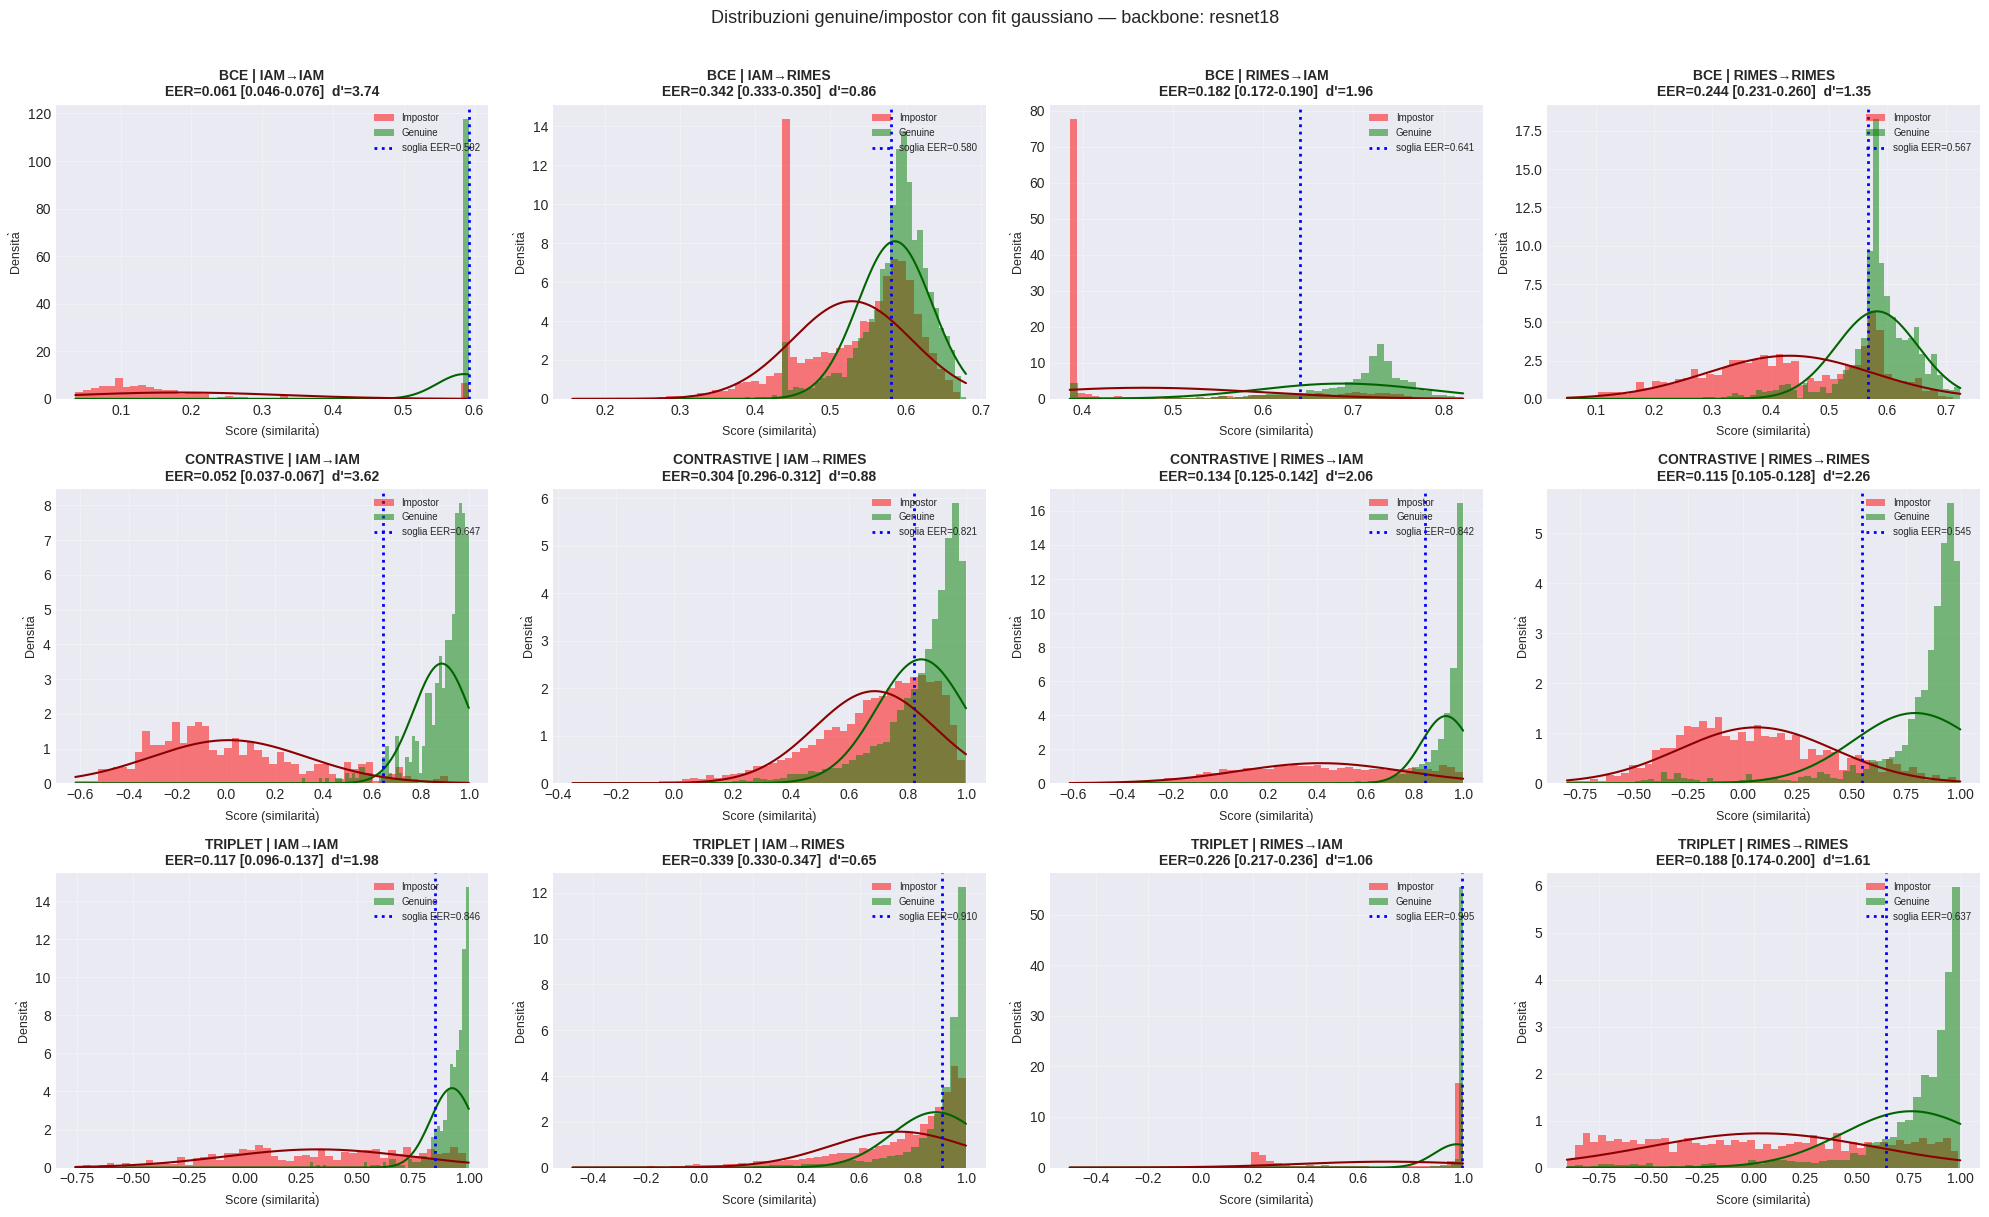

In [59]:
def plot_score_distributions(model_name):
    fig, axes = plt.subplots(len(loss_types), len(dataset_combinations),
                              figsize=(20, 4 * len(loss_types)))
    for i, loss in enumerate(loss_types):
        for j, dataset_comb in enumerate(dataset_combinations):
            ax = axes[i, j]
            data = all_results.get(loss, {}).get(model_name, {}).get(dataset_comb)
            if data is None:
                ax.axis('off')
                continue
            genuine = data['genuine_vals']
            impostor = data['impostor_vals']
            m = computed_metrics[loss][model_name][dataset_comb]
            ax.hist(impostor, bins=50, alpha=0.5, label='Impostor', color='red', density=True)
            ax.hist(genuine, bins=50, alpha=0.5, label='Genuine', color='green', density=True)
            x_range = np.linspace(min(impostor.min(), genuine.min()),
                                   max(impostor.max(), genuine.max()), 200)
            ax.plot(x_range, stats.norm.pdf(x_range, m['mu_genuine'], m['sigma_genuine']),
                    color='darkgreen', linewidth=1.5)
            ax.plot(x_range, stats.norm.pdf(x_range, m['mu_impostor'], m['sigma_impostor']),
                    color='darkred', linewidth=1.5)
            ax.axvline(m['eer_threshold'], color='blue', linestyle=':', linewidth=2,
                       label=f"soglia EER={m['eer_threshold']:.3f}")
            train_ds, test_ds = dataset_comb.split('_to_')
            ax.set_title(f"{loss.upper()} | {train_ds.upper()}\u2192{test_ds.upper()}\n"
                         f"EER={m['eer']:.3f} [{m['eer_ci_low']:.3f}-{m['eer_ci_high']:.3f}]  "
                         f"d'={m['d_prime']:.2f}", fontsize=10, fontweight='bold')
            ax.set_xlabel('Score (similarita\u0300)', fontsize=9)
            ax.set_ylabel('Densita\u0300', fontsize=9)
            ax.legend(fontsize=7, loc='upper right')
            ax.grid(True, alpha=0.3)
    fig.suptitle(f"Distribuzioni genuine/impostor con fit gaussiano \u2014 backbone: {model_name}",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'./images/score_distributions_{model_name}.png', dpi=300, bbox_inches='tight')
    plt.show()


if REPRESENTATIVE_MODEL in computed_metrics.get('bce', {}):
    plot_score_distributions(REPRESENTATIVE_MODEL)
else:
    print(f"Modello rappresentativo '{REPRESENTATIVE_MODEL}' non trovato, salto il plot dettagliato.")

## ROC curve — modello rappresentativo

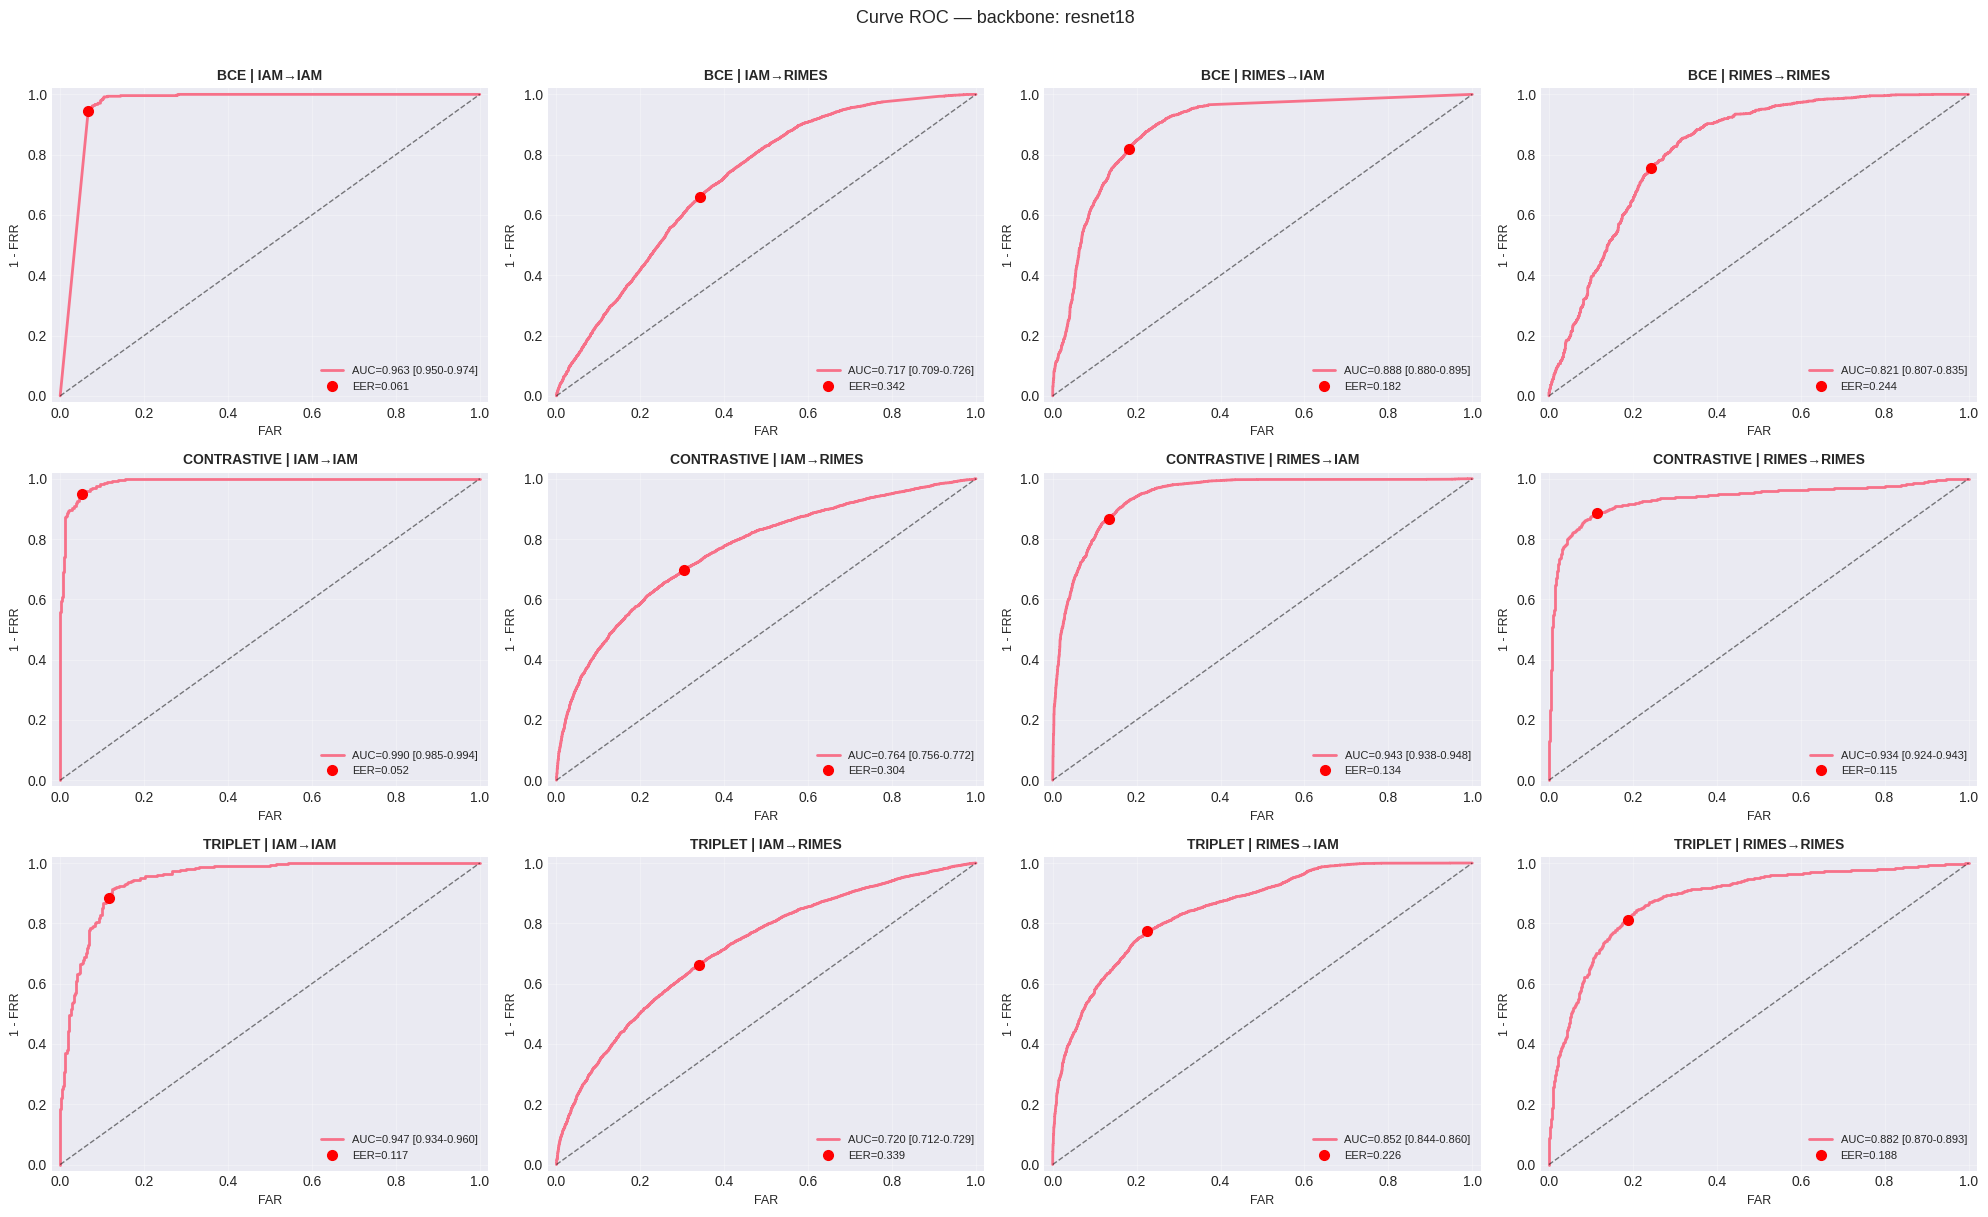

In [60]:
def plot_roc_curves(model_name):
    fig, axes = plt.subplots(len(loss_types), len(dataset_combinations),
                              figsize=(20, 4 * len(loss_types)))
    for i, loss in enumerate(loss_types):
        for j, dataset_comb in enumerate(dataset_combinations):
            ax = axes[i, j]
            m = computed_metrics.get(loss, {}).get(model_name, {}).get(dataset_comb)
            if m is None:
                ax.axis('off')
                continue
            ax.plot(m['fpr'], m['tpr'], linewidth=2,
                    label=f"AUC={m['auc']:.3f} [{m['auc_ci_low']:.3f}-{m['auc_ci_high']:.3f}]")
            ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
            eer_idx = np.nanargmin(np.abs((1 - m['tpr']) - m['fpr']))
            ax.plot(m['fpr'][eer_idx], m['tpr'][eer_idx], 'ro', markersize=7,
                    label=f"EER={m['eer']:.3f}")
            train_ds, test_ds = dataset_comb.split('_to_')
            ax.set_title(f"{loss.upper()} | {train_ds.upper()}\u2192{test_ds.upper()}",
                         fontsize=10, fontweight='bold')
            ax.set_xlabel('FAR', fontsize=9)
            ax.set_ylabel('1 - FRR', fontsize=9)
            ax.legend(fontsize=8, loc='lower right')
            ax.grid(True, alpha=0.3)
            ax.set_xlim([-0.02, 1.02])
            ax.set_ylim([-0.02, 1.02])
    fig.suptitle(f"Curve ROC \u2014 backbone: {model_name}", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'./images/roc_curves_{model_name}.png', dpi=300, bbox_inches='tight')
    plt.show()


if REPRESENTATIVE_MODEL in computed_metrics.get('bce', {}):
    plot_roc_curves(REPRESENTATIVE_MODEL)

## DET curve (log-log) — modello rappresentativo

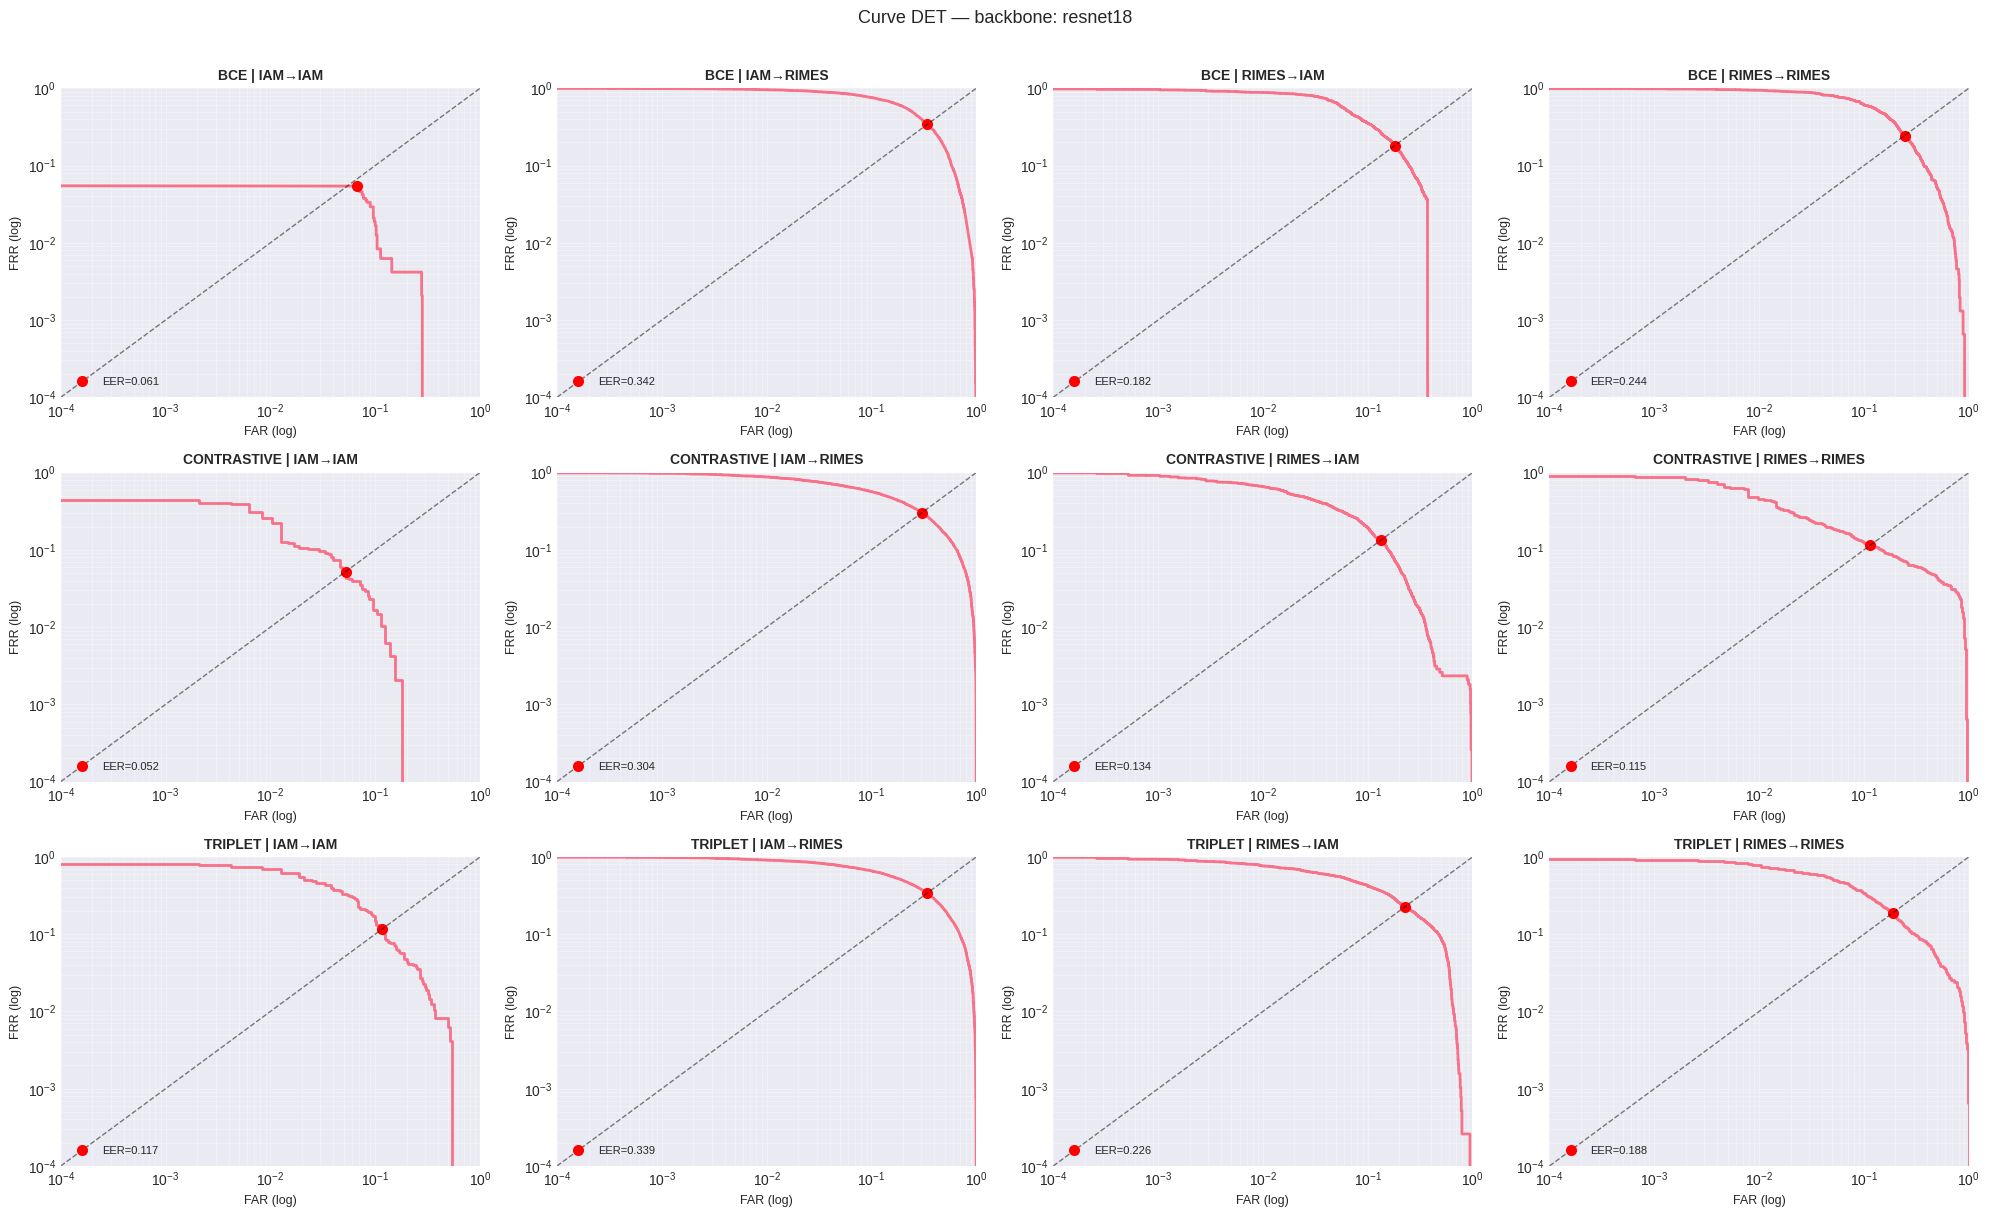

In [61]:
def plot_det_curves(model_name):
    fig, axes = plt.subplots(len(loss_types), len(dataset_combinations),
                              figsize=(20, 4 * len(loss_types)))
    for i, loss in enumerate(loss_types):
        for j, dataset_comb in enumerate(dataset_combinations):
            ax = axes[i, j]
            m = computed_metrics.get(loss, {}).get(model_name, {}).get(dataset_comb)
            if m is None:
                ax.axis('off')
                continue
            frr = 1 - m['tpr']
            ax.loglog(m['fpr'], frr, linewidth=2)
            eer_idx = np.nanargmin(np.abs(frr - m['fpr']))
            ax.plot(m['fpr'][eer_idx], frr[eer_idx], 'ro', markersize=7,
                    label=f"EER={m['eer']:.3f}")
            ax.plot([1e-4, 1], [1e-4, 1], 'k--', linewidth=1, alpha=0.5)
            train_ds, test_ds = dataset_comb.split('_to_')
            ax.set_title(f"{loss.upper()} | {train_ds.upper()}\u2192{test_ds.upper()}",
                         fontsize=10, fontweight='bold')
            ax.set_xlabel('FAR (log)', fontsize=9)
            ax.set_ylabel('FRR (log)', fontsize=9)
            ax.legend(fontsize=8, loc='lower left')
            ax.grid(True, alpha=0.3, which='both')
            ax.set_xlim([1e-4, 1])
            ax.set_ylim([1e-4, 1])
    fig.suptitle(f"Curve DET \u2014 backbone: {model_name}", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'./images/det_curves_{model_name}.png', dpi=300, bbox_inches='tight')
    plt.show()


if REPRESENTATIVE_MODEL in computed_metrics.get('bce', {}):
    plot_det_curves(REPRESENTATIVE_MODEL)

## Training history — modello rappresentativo

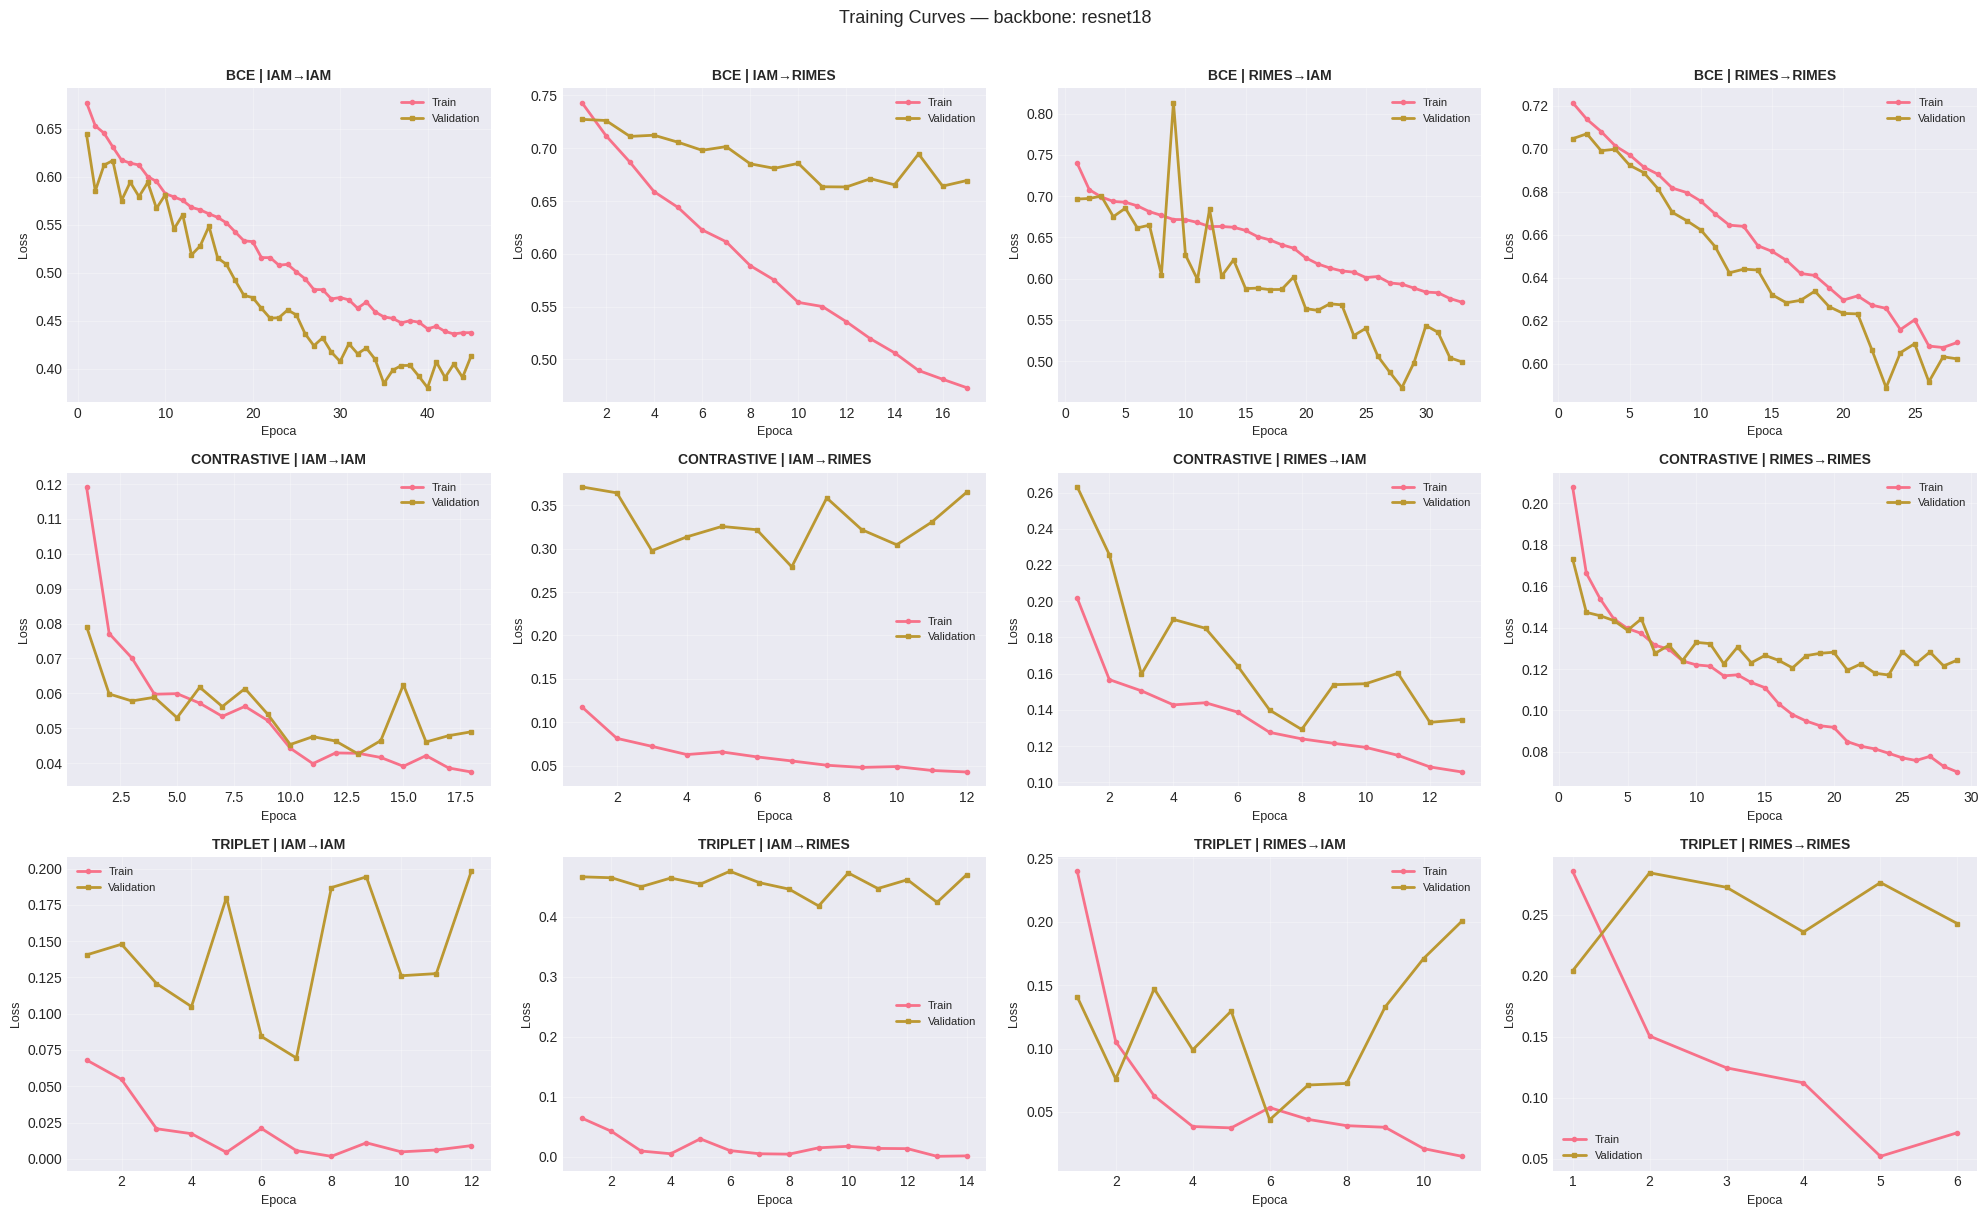

In [62]:
def plot_training_history(model_name):
    fig, axes = plt.subplots(len(loss_types), len(dataset_combinations),
                              figsize=(20, 4 * len(loss_types)))
    for i, loss in enumerate(loss_types):
        for j, dataset_comb in enumerate(dataset_combinations):
            ax = axes[i, j]
            data = all_results.get(loss, {}).get(model_name, {}).get(dataset_comb)
            if data is None:
                ax.axis('off')
                continue
            history = data['history']
            ax.plot(history['epoch'], history['train_loss'], linewidth=2, label='Train', marker='o', markersize=3)
            ax.plot(history['epoch'], history['val_loss'], linewidth=2, label='Validation', marker='s', markersize=3)
            train_ds, test_ds = dataset_comb.split('_to_')
            ax.set_title(f"{loss.upper()} | {train_ds.upper()}\u2192{test_ds.upper()}",
                         fontsize=10, fontweight='bold')
            ax.set_xlabel('Epoca', fontsize=9)
            ax.set_ylabel('Loss', fontsize=9)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
    fig.suptitle(f"Training Curves \u2014 backbone: {model_name}", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'./images/training_history_{model_name}.png', dpi=300, bbox_inches='tight')
    plt.show()


if REPRESENTATIVE_MODEL in computed_metrics.get('bce', {}):
    plot_training_history(REPRESENTATIVE_MODEL)

## Tabelle aggregate Same-dataset / Cross-dataset (bootstrap-based, tutti i backbone)

Complementari alla Tabella 5 "rigorosa" sopra: qui l'aggregazione usa la
t-distribuzione su tutti i backbone disponibili (anche se < 6), utile
come vista aggiuntiva ma NON sostituisce la Tabella 5 richiesta nella
spec, che invece impone tutti e 6 i backbone.

In [63]:
def aggregate_across_models(splits_to_include, metric_keys):
    rows = []
    for loss in loss_types:
        for dataset_comb in splits_to_include:
            vals = {k: [] for k in metric_keys}
            for model_name in computed_metrics.get(loss, {}):
                m = computed_metrics[loss][model_name].get(dataset_comb)
                if m is None:
                    continue
                for k in metric_keys:
                    vals[k].append(m[k])
            n = len(vals[metric_keys[0]])
            if n == 0:
                continue
            row = {'loss': loss.upper(), 'split': dataset_comb, 'n_backbones': n}
            for k in metric_keys:
                arr = np.array(vals[k])
                mean = arr.mean()
                std = arr.std(ddof=1) if n > 1 else 0.0
                se = std / np.sqrt(n) if n > 1 else 0.0
                tcrit = stats.t.ppf(0.975, df=n - 1) if n > 1 else 0.0
                row[f'{k}_mean'] = mean
                row[f'{k}_std'] = std
                row[f'{k}_ci95_low'] = mean - tcrit * se
                row[f'{k}_ci95_high'] = mean + tcrit * se
            rows.append(row)
    return pd.DataFrame(rows)


metric_keys = ['auc', 'eer', 'd_prime', 'decidability', 'accuracy', 'f1',
               'gar_at_far_001', 'gar_at_far_01']

same_agg = aggregate_across_models(['iam_to_iam', 'rimes_to_rimes'], metric_keys)
cross_agg = aggregate_across_models(['iam_to_rimes', 'rimes_to_iam'], metric_keys)
same_agg.to_csv('./same_dataset_aggregated.csv', index=False)
cross_agg.to_csv('./cross_dataset_aggregated.csv', index=False)

print("SAME-DATASET (bootstrap-based, n=n. backbone disponibili):")
print(same_agg[['loss', 'split', 'n_backbones', 'auc_mean', 'auc_std', 'eer_mean', 'eer_std', 'd_prime_mean']].round(3).to_string(index=False))
print("\nCROSS-DATASET (bootstrap-based, n=n. backbone disponibili):")
print(cross_agg[['loss', 'split', 'n_backbones', 'auc_mean', 'auc_std', 'eer_mean', 'eer_std', 'd_prime_mean']].round(3).to_string(index=False))

SAME-DATASET (bootstrap-based, n=n. backbone disponibili):
       loss          split  n_backbones  auc_mean  auc_std  eer_mean  eer_std  d_prime_mean
        BCE     iam_to_iam            6     0.956    0.025     0.090    0.040         3.103
        BCE rimes_to_rimes            6     0.734    0.180     0.309    0.153         1.033
CONTRASTIVE     iam_to_iam            6     0.990    0.004     0.049    0.013         3.641
CONTRASTIVE rimes_to_rimes            6     0.927    0.007     0.129    0.011         2.123
    TRIPLET     iam_to_iam            6     0.924    0.029     0.153    0.036         1.836
    TRIPLET rimes_to_rimes            6     0.888    0.014     0.183    0.011         1.691

CROSS-DATASET (bootstrap-based, n=n. backbone disponibili):
       loss        split  n_backbones  auc_mean  auc_std  eer_mean  eer_std  d_prime_mean
        BCE iam_to_rimes            6     0.621    0.082     0.402    0.069         0.499
        BCE rimes_to_iam            6     0.715    0.133

## Same vs Cross dataset — confronto aggregato (grafico)

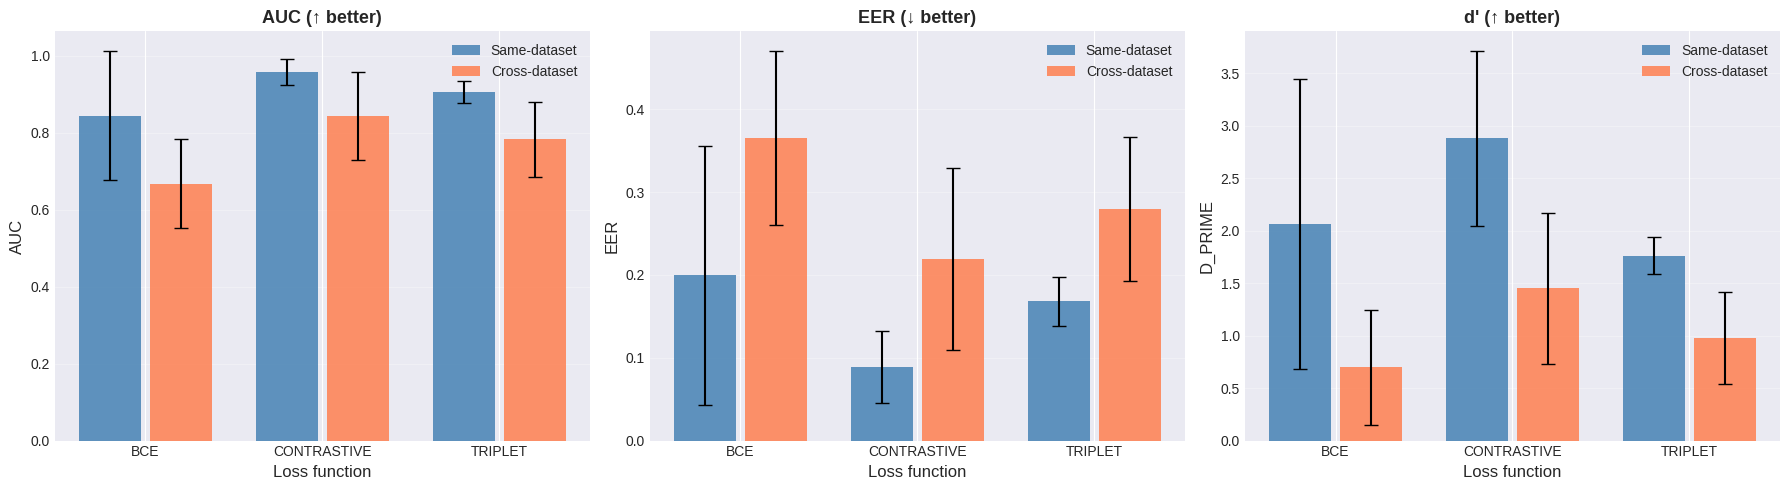

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_compare = ['auc', 'eer', 'd_prime']
titles = ['AUC (\u2191 better)', 'EER (\u2193 better)', "d' (\u2191 better)"]

for idx, (metric, title) in enumerate(zip(metrics_to_compare, titles)):
    ax = axes[idx]
    x_pos = 0
    x_ticks, x_labels = [], []
    for loss in loss_types:
        same_vals_all, cross_vals_all = [], []
        for model_name in computed_metrics.get(loss, {}):
            for ds in ['iam_to_iam', 'rimes_to_rimes']:
                m = computed_metrics[loss][model_name].get(ds)
                if m is not None:
                    same_vals_all.append(m[metric])
            for ds in ['iam_to_rimes', 'rimes_to_iam']:
                m = computed_metrics[loss][model_name].get(ds)
                if m is not None:
                    cross_vals_all.append(m[metric])
        if same_vals_all:
            ax.bar(x_pos, np.mean(same_vals_all), width=0.35,
                   label='Same-dataset' if x_pos == 0 else '', color='steelblue', alpha=0.85)
            ax.errorbar(x_pos, np.mean(same_vals_all), yerr=np.std(same_vals_all, ddof=1),
                        fmt='none', color='black', capsize=5)
        if cross_vals_all:
            ax.bar(x_pos + 0.4, np.mean(cross_vals_all), width=0.35,
                   label='Cross-dataset' if x_pos == 0 else '', color='coral', alpha=0.85)
            ax.errorbar(x_pos + 0.4, np.mean(cross_vals_all), yerr=np.std(cross_vals_all, ddof=1),
                        fmt='none', color='black', capsize=5)
        x_labels.append(loss.upper())
        x_ticks.append(x_pos + 0.2)
        x_pos += 1
    ax.set_xlabel('Loss function', fontsize=12)
    ax.set_ylabel(metric.upper(), fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

#fig.suptitle("Confronto Same- vs Cross-dataset (barre = std tra backbone)", fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig('./images/same_vs_cross_comparison_aggregated.png', dpi=300, bbox_inches='tight')
plt.show()

## Heatmap AUC / EER (media sui backbone)

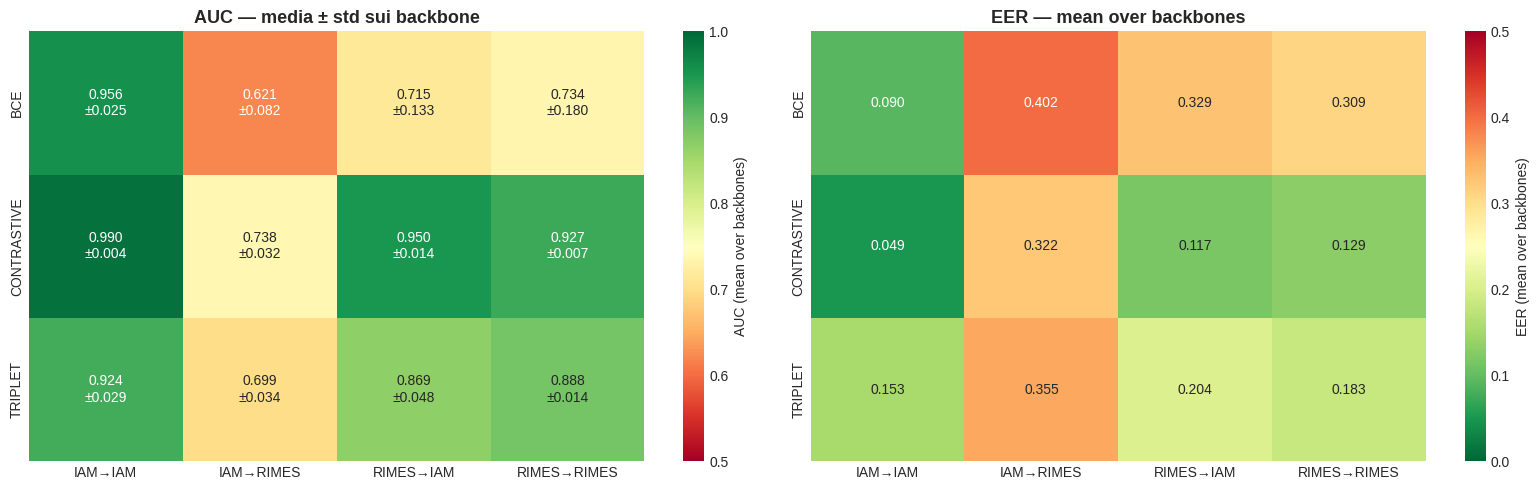

In [65]:
auc_matrix = np.full((len(loss_types), len(dataset_combinations)), np.nan)
eer_matrix = np.full((len(loss_types), len(dataset_combinations)), np.nan)
auc_std_matrix = np.full((len(loss_types), len(dataset_combinations)), np.nan)

for i, loss in enumerate(loss_types):
    for j, dataset_comb in enumerate(dataset_combinations):
        vals = [computed_metrics[loss][model_name][dataset_comb]['auc']
                for model_name in computed_metrics.get(loss, {})
                if dataset_comb in computed_metrics[loss][model_name]]
        eer_vals = [computed_metrics[loss][model_name][dataset_comb]['eer']
                    for model_name in computed_metrics.get(loss, {})
                    if dataset_comb in computed_metrics[loss][model_name]]
        if vals:
            auc_matrix[i, j] = np.mean(vals)
            auc_std_matrix[i, j] = np.std(vals, ddof=1) if len(vals) > 1 else 0.0
            eer_matrix[i, j] = np.mean(eer_vals)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
labels_x = [dc.replace('_to_', '\u2192').upper() for dc in dataset_combinations]
labels_y = [l.upper() for l in loss_types]
annot_auc = np.array([[f"{auc_matrix[i,j]:.3f}\n\u00b1{auc_std_matrix[i,j]:.3f}"
                        for j in range(len(dataset_combinations))]
                       for i in range(len(loss_types))])

sns.heatmap(auc_matrix, annot=annot_auc, fmt='', cmap='RdYlGn',
            xticklabels=labels_x, yticklabels=labels_y,
            ax=axes[0], cbar_kws={'label': 'AUC (mean over backbones)'}, vmin=0.5, vmax=1.0)
axes[0].set_title("AUC \u2014 media \u00b1 std sui backbone", fontsize=13, fontweight='bold')

sns.heatmap(eer_matrix, annot=True, fmt='.3f', cmap='RdYlGn_r',
            xticklabels=labels_x, yticklabels=labels_y,
            ax=axes[1], cbar_kws={'label': 'EER (mean over backbones)'}, vmin=0.0, vmax=0.5)
axes[1].set_title("EER \u2014 mean over backbones", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('./images/metrics_heatmap_aggregated.png', dpi=300, bbox_inches='tight')
plt.show()

## Radar chart — confronto backbone (media su tutti loss/split), scala ibrida
Il floor di ogni asse resta FISSO e ha un significato assoluto (es. 0.5 =
chance level per AUC/GAR/1-EER, 0 per d'). Il ceiling invece e' dinamico:
= il massimo valore osservato tra i backbone su quell'asse (con un margine
del 5%), cosi' il grafico non resta "piccolo" ma la posizione zero resta
sempre ancorata a un riferimento assoluto, non al backbone peggiore.

(chiave in computed_metrics, label, invert, floor_assoluto)

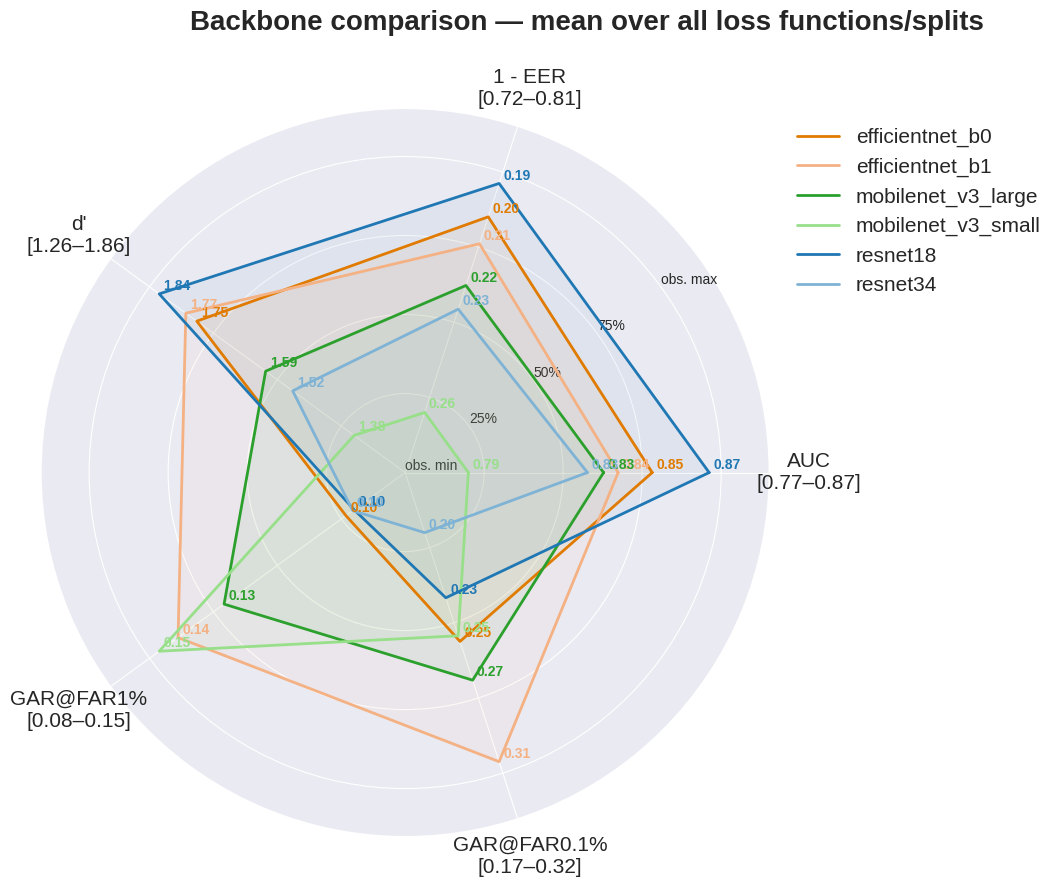


Raw values (mean over all loss/split) used in the radar chart:

                       AUC      d'  GAR@FAR1%  GAR@FAR0.1%     EER
backbone                                                          
efficientnet_b0     0.8494  1.7471     0.0999       0.2531  0.2022
efficientnet_b1     0.8380  1.7728     0.1427       0.3098  0.2105
mobilenet_v3_large  0.8332  1.5857     0.1310       0.2713  0.2234
mobilenet_v3_small  0.7879  1.3786     0.1475       0.2504  0.2626
resnet18            0.8685  1.8351     0.0978       0.2325  0.1919
resnet34            0.8278  1.5223     0.0982       0.2018  0.2307

Effective axis ranges (extended floor — observed max +5%):
  AUC: [0.767 - 0.873]
  1 - EER: [0.719 - 0.812]
  d': [1.259 - 1.858]
  GAR@FAR1%: [0.085 - 0.150]
  GAR@FAR0.1%: [0.173 - 0.315]


In [66]:
RADAR_METRICS = [
    ('auc',            'AUC',         False),
    ('eer',            '1 - EER',     True),
    ('d_prime',        "d'",          False),
    ('gar_at_far_001', 'GAR@FAR1%',   False),
    ('gar_at_far_01',  'GAR@FAR0.1%', False),
]
TOP_MARGIN_FRAC = 0.05       # margin above the observed max (5% of the span)
MIN_RADIUS_FRACTION = 0.20   # the lowest value must sit at least at 20% of the radius, not at 0

FAMILY_COLORS = {
    'resnet18':            '#1f77b4',
    'resnet34':            '#7fb3d5',
    'efficientnet_b0':     '#e07b00',
    'efficientnet_b1':     '#f4b183',
    'mobilenet_v3_large':  '#2ca02c',
    'mobilenet_v3_small':  '#98df8a',
}

def aggregate_metric_per_backbone(metric_key):
    out = {}
    for model_name in MODELS_TO_ANALYZE:
        vals = []
        for loss in loss_types:
            for dataset_comb in dataset_combinations:
                m = computed_metrics.get(loss, {}).get(model_name, {}).get(dataset_comb)
                if m is not None and metric_key in m and not (isinstance(m[metric_key], float) and np.isnan(m[metric_key])):
                    vals.append(m[metric_key])
        out[model_name] = np.mean(vals) if vals else np.nan
    return out


raw_values = {}
scaled_values = {}
axis_ranges = {}

for metric_key, label, invert in RADAR_METRICS:
    agg = aggregate_metric_per_backbone(metric_key)
    oriented = {k: (1 - v if not np.isnan(v) else np.nan) for k, v in agg.items()} if invert else agg
    raw_values[label] = oriented

    finite_vals = np.array([v for v in oriented.values() if not np.isnan(v)])
    observed_min = finite_vals.min() if len(finite_vals) else 0.0
    observed_max = finite_vals.max() if len(finite_vals) else 1.0
    span = observed_max - observed_min
    if span <= 0:
        span = max(abs(observed_max), 1e-6)

    ceiling = observed_max + span * TOP_MARGIN_FRAC

    # Floor chosen so that (observed_min - floor) / (ceiling - floor)
    # equals exactly MIN_RADIUS_FRACTION -> the lowest point is always
    # visible at that minimum radius, never collapsed against the center.
    # Solving the equation for floor:
    floor = (observed_min - MIN_RADIUS_FRACTION * ceiling) / (1 - MIN_RADIUS_FRACTION)

    if np.isclose(floor, ceiling):
        ceiling = floor + 1e-6

    axis_ranges[label] = (floor, ceiling)

    scaled = {}
    for model_name, v in oriented.items():
        if np.isnan(v):
            scaled[model_name] = 0.0
        else:
            scaled[model_name] = (v - floor) / (ceiling - floor)
    scaled_values[label] = scaled

labels = [lbl for _, lbl, _ in RADAR_METRICS]

# --- Plot ---
n_axes = len(labels)
angles = np.linspace(0, 2 * np.pi, n_axes, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(11, 11), subplot_kw=dict(polar=True))

for model_name in MODELS_TO_ANALYZE:
    color = FAMILY_COLORS.get(model_name, '#999999')
    values = [scaled_values[label][model_name] for label in labels]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=model_name, color=color)
    ax.fill(angles, values, alpha=0.06, color=color)

    for angle, label, v_scaled in zip(angles[:-1], labels, values[:-1]):
        real_val = raw_values[label][model_name]
        txt = f"{real_val:.2f}" if label != '1 - EER' else f"{(1 - real_val):.2f}"
        ax.annotate(txt, xy=(angle, v_scaled), xytext=(3, 3), textcoords='offset points',
                    fontsize=10, color=color, fontweight='bold')

tick_labels = [f"{lbl}\n[{axis_ranges[lbl][0]:.2f}\u2013{axis_ranges[lbl][1]:.2f}]" for lbl in labels]
ax.set_xticks(angles[:-1])
ax.set_xticklabels(tick_labels, fontsize=15)
ax.tick_params(axis='x', pad=22)

ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['obs. min', '25%', '50%', '75%', 'obs. max'], fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_rlabel_position(180 / n_axes)

ax.set_title("Backbone comparison — mean over all loss functions/splits\n",
             #"(dynamic floor with extended margin; ceiling = observed max +5%; colors by architecture family)",
             fontsize=20, fontweight='bold', x=0.75)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.0), fontsize=15)
plt.tight_layout()
plt.savefig('./images/radar_backbone_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Supporting table
raw_values_display = dict(raw_values)
raw_values_display['EER'] = {k: (1 - v) for k, v in raw_values['1 - EER'].items()}
del raw_values_display['1 - EER']
radar_table = pd.DataFrame(raw_values_display)
radar_table.index.name = 'backbone'
radar_table = radar_table.round(4)
print("\nRaw values (mean over all loss/split) used in the radar chart:\n")
print(radar_table.to_string())
print("\nEffective axis ranges (extended floor — observed max +5%):")
for label, (f, c) in axis_ranges.items():
    print(f"  {label}: [{f:.3f} - {c:.3f}]")
radar_table.to_csv('./tables/radar_backbone_values.csv')

## Test di Wilcoxon a coppie appaiate tra loss (su AUC)

In [67]:
def build_paired_auc(loss_a, loss_b):
    pairs = []
    for model_name in computed_metrics.get(loss_a, {}):
        for dataset_comb in computed_metrics[loss_a][model_name]:
            m_b = computed_metrics.get(loss_b, {}).get(model_name, {}).get(dataset_comb)
            if m_b is not None:
                pairs.append((computed_metrics[loss_a][model_name][dataset_comb]['auc'], m_b['auc']))
    if not pairs:
        return np.array([]), np.array([])
    x, y = zip(*pairs)
    return np.array(x), np.array(y)


def wilcoxon_with_effect(x, y):

    diff = x - y

    diff_nz = diff[diff != 0]

    if len(diff_nz) < 4:
        return dict(
            n=len(diff),
            n_nonzero=len(diff_nz),
            n_positive=np.nan,
            n_negative=np.nan,
            statistic=np.nan,
            p_value=np.nan,
            effect_size=np.nan
        )

    # Count positive and negative differences
    n_positive = np.sum(diff_nz > 0)
    n_negative = np.sum(diff_nz < 0)

    ranks = stats.rankdata(np.abs(diff_nz))

    r_plus = ranks[diff_nz > 0].sum()
    r_minus = ranks[diff_nz < 0].sum()

    stat, p = stats.wilcoxon(x, y)

    effect = (r_plus - r_minus) / (r_plus + r_minus)

    return dict(
        n=len(diff),
        n_nonzero=len(diff_nz),
        n_positive=n_positive,
        n_negative=n_negative,
        statistic=stat,
        p_value=p,
        effect_size=effect
    )


wilcoxon_rows = []
for loss_a, loss_b in combinations(loss_types, 2):
    x, y = build_paired_auc(loss_a, loss_b)
    if len(x) == 0:
        continue
    res = wilcoxon_with_effect(x, y)
    res['loss_a'] = loss_a
    res['loss_b'] = loss_b
    res['mean_auc_a'] = x.mean()
    res['mean_auc_b'] = y.mean()
    wilcoxon_rows.append(res)
    sig = "significativo (p<0.05)" if (not np.isnan(res['p_value']) and res['p_value'] < 0.05) else "non significativo"
    print(
        f"{loss_a.upper()} vs {loss_b.upper()} "
        f"(n={res['n']}, +={res['n_positive']}, -={res['n_negative']}, "
        f"n_diff≠0={res['n_nonzero']}): "
        f"AUC {res['mean_auc_a']:.3f} vs {res['mean_auc_b']:.3f}, "
        f"W={res['statistic']:.2f} "
        f"p={res['p_value']:.7f} "
        f"effect={res['effect_size']:.3f}"
    )                                                           

wilcoxon_df = pd.DataFrame(wilcoxon_rows)
wilcoxon_df.to_csv('./wilcoxon_loss_comparison.csv', index=False)

BCE vs CONTRASTIVE (n=24, +=1, -=23, n_diff≠0=24): AUC 0.756 vs 0.901, W=1.00 p=0.0000002 effect=-0.993
BCE vs TRIPLET (n=24, +=8, -=16, n_diff≠0=24): AUC 0.756 vs 0.845, W=63.00 p=0.0115161 effect=-0.580
CONTRASTIVE vs TRIPLET (n=24, +=24, -=0, n_diff≠0=24): AUC 0.901 vs 0.845, W=0.00 p=0.0000001 effect=1.000


In [68]:
print("""
File generati (Results):
  tables/table1_protocol.md         -> Tabella 1 (+1b supplementare)
  tables/table2_auc.md              -> Tabella 2 (AUC per split)
  tables/table3_eer.md              -> Tabella 3 (EER per split)
  tables/table4_full.md             -> Tabella 4 (long format)
  tables/table4_full_export.csv     -> Tabella 4 in CSV
  tables/table5_aggregated.md       -> Tabella 5 (mean+/-std, solo 6/6 backbone)
  tables/missing_configurations.md  -> Configurazioni mancanti (CSV/log)
  tables/training_dynamics.csv      -> Tabella C (epoche/early stopping)
  same_dataset_aggregated.csv       -> Aggregato bootstrap-based (supplementare)
  cross_dataset_aggregated.csv      -> Aggregato bootstrap-based (supplementare)
  wilcoxon_loss_comparison.csv      -> Test di significativita'
  known_confounds.txt               -> Blocco Limitations
  images/*.png                      -> Tutti i plot (distribuzioni, ROC, DET, training, heatmap)
""")


File generati (Results):
  tables/table1_protocol.md         -> Tabella 1 (+1b supplementare)
  tables/table2_auc.md              -> Tabella 2 (AUC per split)
  tables/table3_eer.md              -> Tabella 3 (EER per split)
  tables/table4_full.md             -> Tabella 4 (long format)
  tables/table4_full_export.csv     -> Tabella 4 in CSV
  tables/table5_aggregated.md       -> Tabella 5 (mean+/-std, solo 6/6 backbone)
  tables/missing_configurations.md  -> Configurazioni mancanti (CSV/log)
  tables/training_dynamics.csv      -> Tabella C (epoche/early stopping)
  same_dataset_aggregated.csv       -> Aggregato bootstrap-based (supplementare)
  cross_dataset_aggregated.csv      -> Aggregato bootstrap-based (supplementare)
  wilcoxon_loss_comparison.csv      -> Test di significativita'
  known_confounds.txt               -> Blocco Limitations
  images/*.png                      -> Tutti i plot (distribuzioni, ROC, DET, training, heatmap)

